# CT transmission: Poisson-count or Gaussian-rate observation

This notebook now supports two observation models built from the **same nonlinear
Beer--Lambert map**

$$
F(x)=\lambda(x)=N_0\exp[-A_\Omega a(x)]+b.
$$

Choose the mode with `cfg.observation_mode`:

1. **Original Poisson-count mode**
   $$
   y_i\mid x\sim\operatorname{Poisson}(F_i(x)).
   $$

2. **Gaussian-rate diagnostic mode**
   $$
   y=F(x_0)+\xi,
   \qquad
   \xi\sim\mathcal N(0,\sigma_F^2 I).
   $$
   The corresponding reward is
   $$
   r_F(x;y)
   =-
   \frac{1}{2\sigma_F^2}
   \|F(x)-y\|_2^2,
   $$
   up to an additive constant independent of $x$.

The Gaussian-rate mode directly tests the question:

> Given a nonlinear function $F$ and a ground truth $x_0$, can the sampler use
> $F(x_0)$ as its observation and generate samples concentrated around $x_0$?

Set `cfg.sample_observation_noise=False` to use the exact observation
$y=F(x_0)$ while retaining `cfg.gaussian_rate_noise_std` as the assumed
likelihood standard deviation.

Run order: **Config → Setup → Data → Diagnostics → Methods → Results.**
Stop at the Diagnostics gate if anything fails there.

## 1. Configuration

Everything tunable lives here. No environment variables.

In [1]:
from dataclasses import dataclass, field
import pathlib

@dataclass
class Cfg:
    # -- observation model -------------------------------------------------
    # "poisson_counts": y_i ~ Poisson(F_i(x0))
    # "gaussian_rate": y = F(x0) + Normal(0, gaussian_rate_noise_std^2 I)
    observation_mode: str = "gaussian_rate"

    # In Gaussian-rate mode, this is both the simulated-noise standard
    # deviation and the standard deviation used by the Gaussian likelihood.
    gaussian_rate_noise_std: float = 0.10

    # True: sample the configured observation noise.
    # False: use the exact mean observation y = F(x0).
    sample_observation_noise: bool = True

    # -- geometry -----------------------------------------------------------
    img_size:        int   = 64

    # A 64 x 64 full ray grid gives m = 4096 observation coordinates, matching
    # the 64 x 64 image dimension for the requested square-system diagnostic.
    # These values remain tunable.
    num_angles:      int   = 64
    num_detectors:   int   = 64
    mask_type:       str   = "full"
    mask_fraction:   float = 1.0
    mask_seed:       int   = 0

    # -- transmission / photon-rate map ------------------------------------
    n0_photons:      float = 1000.0
    background_counts: float = 0.0

    # a(x) = atten_scale * link(atten_gain * (x + atten_offset))
    atten_scale:     float = 4.00
    atten_link:      str   = "affine"       # "affine" | "softplus"
    atten_offset:    float = 1.00           # affine: 1.0 -> air at x=-1
    atten_gain:      float = 1.00

    # -- score prior -------------------------------------------------------
    # Point this at the .pt you trained on the ellipse-phantom data.
    prior_dir:       str   = "/usr/workspace/mlml/synthetic_64_256/mri_score_prior_dsm2000_outputs"
    checkpoint:      str   = ""     # "" -> discover newest compatible checkpoint
    base_channels:   int   = 32
    time_emb_dim:    int   = 128

    # -- ground truth ------------------------------------------------------
    truth_index:     int   = 0
    truth_seed:      int   = 12345

    # -- sampling ----------------------------------------------------------
    n_samples:       int   = 512
    n_steps:         int   = 200
    seed:            int   = 0
    reward_chunk:    int   = 8
    angle_chunk:     int   = 20

    # -- SMC ---------------------------------------------------------------
    smc_levels:      int   = 5
    smc_ref_levels:  int   = 8
    smc_steps:       tuple = (100, 120, 140, 160, 180, 200, 220, 240)
    smc_n_ref_tail:  int   = 256
    smc_surrogate:   str   = "none"    # none | inv_m | inv_sqrt_m
    smc_tail_stats:  str   = ""

    # Full likelihood; no automatic ESS calibration/tempering.
    smc_likelihood_strength: float = 1.0
    smc_auto_calibrate_strength: bool = False

    # -- output ------------------------------------------------------------
    outdir:          str   = "ct_transmission_outputs"
    save_figures:    bool  = True

cfg = Cfg()

# Resolve the two files that live next to the trained prior. Same glob-and-
# take-newest logic as AUTO_DISCOVER_LATEST_PRIOR_CHECKPOINT.
def _latest(directory, patterns):
    """First pattern that matches wins; newest file within that pattern."""
    d = pathlib.Path(directory).expanduser()
    if not d.exists():
        return None
    for pat in patterns:
        hits = [p for p in d.glob(pat) if p.is_file()]
        if hits:
            return max(hits, key=lambda p: p.stat().st_mtime)
    return None

_pd = pathlib.Path(cfg.prior_dir).expanduser()
if not cfg.checkpoint:
    _ck = _latest(
        _pd,
        [
            "score_prior*_trained.pt",
            "score_prior_singlecoil_mri_*.pt",
            "score_prior*.pt",
            "*.pt",
        ],
    )
    cfg.checkpoint = str(_ck) if _ck else ""

if not cfg.smc_tail_stats:
    _ts = _latest(
        _pd,
        ["score_prior_tail_behavior_stats*.npz", "*tail*stats*.npz"],
    )
    cfg.smc_tail_stats = str(_ts) if _ts else ""

OUT = pathlib.Path(cfg.outdir)
OUT.mkdir(parents=True, exist_ok=True)

print("observation mode:", cfg.observation_mode)
print("Gaussian rate std:", cfg.gaussian_rate_noise_std)
print("sample observation noise:", cfg.sample_observation_noise)
print("geometry:", cfg.num_angles, "angles x", cfg.num_detectors, "detectors")
print("prior dir  :", _pd, " exists:", _pd.exists())
print("checkpoint :", cfg.checkpoint or "(NONE FOUND)")
print("tail stats :", cfg.smc_tail_stats or "(will recompute)")
print("SMC likelihood strength:", cfg.smc_likelihood_strength)
print("SMC auto calibration:", cfg.smc_auto_calibrate_strength)

if _pd.exists() and not cfg.checkpoint:
    print()
    print("  .pt files present in prior_dir:")
    for p in sorted(_pd.rglob("*.pt")):
        print("   ", p)
    print("  set cfg.checkpoint to one of these explicitly.")

cfg

observation mode: gaussian_rate
Gaussian rate std: 0.1
sample observation noise: True
geometry: 64 angles x 64 detectors
prior dir  : /usr/workspace/mlml/synthetic_64_256/mri_score_prior_dsm2000_outputs  exists: True
checkpoint : /usr/workspace/mlml/synthetic_64_256/mri_score_prior_dsm2000_outputs/score_prior_singlecoil_mri_64_dsm2000_trained.pt
tail stats : /usr/workspace/mlml/synthetic_64_256/mri_score_prior_dsm2000_outputs/score_prior_tail_behavior_stats.npz
SMC likelihood strength: 1.0
SMC auto calibration: False


Cfg(observation_mode='gaussian_rate', gaussian_rate_noise_std=0.1, sample_observation_noise=True, img_size=64, num_angles=64, num_detectors=64, mask_type='full', mask_fraction=1.0, mask_seed=0, n0_photons=1000.0, background_counts=0.0, atten_scale=4.0, atten_link='affine', atten_offset=1.0, atten_gain=1.0, prior_dir='/usr/workspace/mlml/synthetic_64_256/mri_score_prior_dsm2000_outputs', checkpoint='/usr/workspace/mlml/synthetic_64_256/mri_score_prior_dsm2000_outputs/score_prior_singlecoil_mri_64_dsm2000_trained.pt', base_channels=32, time_emb_dim=128, truth_index=0, truth_seed=12345, n_samples=512, n_steps=200, seed=0, reward_chunk=8, angle_chunk=20, smc_levels=5, smc_ref_levels=8, smc_steps=(100, 120, 140, 160, 180, 200, 220, 240), smc_n_ref_tail=256, smc_surrogate='none', smc_tail_stats='/usr/workspace/mlml/synthetic_64_256/mri_score_prior_dsm2000_outputs/score_prior_tail_behavior_stats.npz', smc_likelihood_strength=1.0, smc_auto_calibrate_strength=False, outdir='ct_transmission_outp

In [2]:
# ============================================================
# Materialize the embedded CT helper modules for this notebook
# ============================================================
# A file shown as an attachment or pasted into another notebook cell is not
# automatically importable. Python imports modules only from files located on
# sys.path. This cell writes the exact helper sources beside the running
# notebook (inside a dedicated subdirectory) and puts that directory first.

import os
import sys
import pathlib
import importlib

CT_CODE_DIR = (pathlib.Path.cwd() / "_ct_helpers_embedded_gaussian_rate").resolve()
CT_CODE_DIR.mkdir(parents=True, exist_ok=True)

_EMBEDDED_CT_MODULES = {
    'ct_common.py': '"""Score-prior network and VP-SDE helpers.\n\nExtracted VERBATIM from the SMC notebook so the CT experiment loads the same\narchitecture the checkpoint was trained with.  Do not edit: if the notebook\'s\nmodel changes, re-extract rather than hand-patching.\n\nForward SDE (as used throughout):   x_t = (1-t) x_0 + sqrt(t(2-t)) eps\n"""\n\nimport math\nimport numpy as np\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\nfrom torch.utils.data import Dataset\n\nclass SinusoidalTimeEmbedding(nn.Module):\n    def __init__(self, dim: int):\n        super().__init__()\n        self.dim = int(dim)\n\n    def forward(self, t: torch.Tensor) -> torch.Tensor:\n        # t: (B,)\n        half = self.dim // 2\n        device = t.device\n        freqs = torch.exp(torch.linspace(math.log(1.0), math.log(1000.0), half, device=device))\n        args = t[:, None] * freqs[None, :]\n        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)\n        if emb.shape[-1] < self.dim:\n            emb = F.pad(emb, (0, self.dim - emb.shape[-1]))\n        return emb\n\n\nclass TimeBlock(nn.Module):\n    def __init__(self, in_ch: int, out_ch: int, emb_dim: int):\n        super().__init__()\n        groups = 8 if out_ch % 8 == 0 else 1\n        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)\n        self.norm1 = nn.GroupNorm(groups, out_ch)\n        self.emb_proj = nn.Linear(emb_dim, out_ch)\n        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)\n        self.norm2 = nn.GroupNorm(groups, out_ch)\n        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()\n\n    def forward(self, x, emb):\n        h = self.conv1(x)\n        h = self.norm1(h)\n        h = F.silu(h)\n        h = h + self.emb_proj(emb)[:, :, None, None]\n        h = self.conv2(h)\n        h = self.norm2(h)\n        h = F.silu(h)\n        return h + self.skip(x)\n\n\nclass SmallUNetScore(nn.Module):\n    def __init__(self, in_ch=1, base_ch=32, emb_dim=128):\n        super().__init__()\n        self.time_mlp = nn.Sequential(\n            SinusoidalTimeEmbedding(emb_dim),\n            nn.Linear(emb_dim, emb_dim),\n            nn.SiLU(),\n            nn.Linear(emb_dim, emb_dim),\n        )\n        self.enc1 = TimeBlock(in_ch, base_ch, emb_dim)\n        self.enc2 = TimeBlock(base_ch, base_ch * 2, emb_dim)\n        self.enc3 = TimeBlock(base_ch * 2, base_ch * 4, emb_dim)\n        self.pool = nn.AvgPool2d(2)\n        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, 2, stride=2)\n        self.dec2 = TimeBlock(base_ch * 4, base_ch * 2, emb_dim)\n        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, 2, stride=2)\n        self.dec1 = TimeBlock(base_ch * 2, base_ch, emb_dim)\n        self.out = nn.Conv2d(base_ch, in_ch, 3, padding=1)\n\n    def forward(self, x, t):\n        # t should be in [0,1], shape (B,)\n        emb = self.time_mlp(t)\n        e1 = self.enc1(x, emb)\n        e2 = self.enc2(self.pool(e1), emb)\n        e3 = self.enc3(self.pool(e2), emb)\n        u2 = self.up2(e3)\n        if u2.shape[-2:] != e2.shape[-2:]:\n            u2 = F.interpolate(u2, size=e2.shape[-2:], mode="bilinear", align_corners=False)\n        d2 = self.dec2(torch.cat([u2, e2], dim=1), emb)\n        u1 = self.up1(d2)\n        if u1.shape[-2:] != e1.shape[-2:]:\n            u1 = F.interpolate(u1, size=e1.shape[-2:], mode="bilinear", align_corners=False)\n        d1 = self.dec1(torch.cat([u1, e1], dim=1), emb)\n        return self.out(d1)\n\n\ndef dsm_loss(model: nn.Module, x0: torch.Tensor,\n             dsm_t_min: float = 1e-3, dsm_t_max: float = 0.98,\n             dsm_weight_by_sigma2: bool = True) -> torch.Tensor:\n    """Denoising score-matching loss.  Only needed if you retrain the prior;\n    the CT experiment loads a checkpoint and never calls this."""\n    B = x0.shape[0]\n    t = torch.rand(B, device=x0.device) * (dsm_t_max - dsm_t_min) + dsm_t_min\n    sigma = torch.sqrt(torch.clamp(t * (2.0 - t), min=1e-8)).view(B, 1, 1, 1)\n    mean = (1.0 - t).view(B, 1, 1, 1) * x0\n    eps = torch.randn_like(x0)\n    xt = mean + sigma * eps\n    target = -eps / sigma\n    pred = model(xt, t)\n    sq = (pred - target) ** 2\n    if dsm_weight_by_sigma2:\n        sq = sq * sigma ** 2\n    return sq.mean()\n\n\n# ---------------------------------------------------------------------------\n# VP-SDE helpers (same parameterisation as the notebooks)\n# ---------------------------------------------------------------------------\n\ndef sde_mean_std(t: torch.Tensor):\n    """x_t = mean(t) * x_0 + std(t) * eps."""\n    return (1.0 - t), torch.sqrt(torch.clamp(t * (2.0 - t), min=1e-8))\n\n\ndef build_score_model(base_ch: int, emb_dim: int, device) -> nn.Module:\n    return SmallUNetScore(in_ch=1, base_ch=int(base_ch), emb_dim=int(emb_dim)).to(device)\n\n\ndef _extract_state_dict(ckpt):\n    """Find the weights inside a checkpoint dict.\n\n    The SMC notebook saves as ``{"model": state_dict, "optimizer": ..., ...}``\n    and loads with ``ckpt["model"]``.  That key is checked first; the others are\n    fallbacks for checkpoints saved by other scripts.\n    """\n    if not isinstance(ckpt, dict):\n        return ckpt\n    for key in ("model", "model_state_dict", "state_dict", "net", "ema", "weights"):\n        if key in ckpt and isinstance(ckpt[key], dict):\n            return ckpt[key]\n    # A bare state_dict is a dict whose values are all tensors.\n    if ckpt and all(torch.is_tensor(v) for v in ckpt.values()):\n        return ckpt\n    raise KeyError(\n        "Could not find weights in the checkpoint. Top-level keys: "\n        f"{sorted(ckpt.keys())}. Pass the right one via state_dict_key=."\n    )\n\n\ndef infer_model_dims(state):\n    """Recover (in_ch, base_ch, emb_dim) from a SmallUNetScore state_dict.\n\n    Lets the notebook build a model that matches the checkpoint instead of\n    guessing, which otherwise fails with a wall of missing-key errors.\n    """\n    state = {k[len("module."):] if k.startswith("module.") else k: v\n             for k, v in state.items()}\n    dims = {}\n    if "time_mlp.1.weight" in state:\n        dims["emb_dim"] = int(state["time_mlp.1.weight"].shape[0])\n    if "enc1.conv1.weight" in state:\n        w = state["enc1.conv1.weight"]\n        dims["base_ch"] = int(w.shape[0])\n        dims["in_ch"] = int(w.shape[1])\n    if "out.weight" in state:\n        dims.setdefault("in_ch", int(state["out.weight"].shape[0]))\n    return dims\n\n\ndef load_score_checkpoint(model, path, device, state_dict_key=None, strict=True,\n                          verbose=True):\n    """Load a checkpoint into ``model``.  Returns True on success.\n\n    Raises a readable error on a dimension mismatch rather than dumping every\n    missing parameter name.\n    """\n    import pathlib\n    path = pathlib.Path(path).expanduser()\n    if not path.exists():\n        return False\n    try:\n        ckpt = torch.load(str(path), map_location=device, weights_only=False)\n    except TypeError:\n        ckpt = torch.load(str(path), map_location=device)\n\n    state = ckpt[state_dict_key] if state_dict_key else _extract_state_dict(ckpt)\n    state = {k[len("module."):] if k.startswith("module.") else k: v\n             for k, v in state.items()}\n\n    want = infer_model_dims(state)\n    have = {"emb_dim": int(model.time_mlp[1].weight.shape[0]),\n            "base_ch": int(model.enc1.conv1.weight.shape[0]),\n            "in_ch": int(model.enc1.conv1.weight.shape[1])}\n    bad = {k: (have[k], want[k]) for k in want if k in have and have[k] != want[k]}\n    if bad:\n        raise ValueError(\n            "Checkpoint architecture does not match the model you built:\\n" +\n            "\\n".join(f"    {k}: model has {h}, checkpoint has {w}"\n                       for k, (h, w) in bad.items()) +\n            "\\n  Fix the corresponding cfg fields (base_channels / time_emb_dim), "\n            "or call build_score_model_for_checkpoint(path, device)."\n        )\n\n    model.load_state_dict(state, strict=strict)\n    model.eval()\n    if verbose and isinstance(ckpt, dict):\n        meta = {k: ckpt[k] for k in ("global_step", "saved_at_unix_time")\n                if k in ckpt and not torch.is_tensor(ckpt[k])}\n        if "config" in ckpt and isinstance(ckpt["config"], dict):\n            keep = {k: v for k, v in ckpt["config"].items()\n                    if k in ("IMG_SIZE", "BASE_CHANNELS", "TIME_EMB_DIM",\n                             "NUM_TRAIN_STEPS", "SEED", "DATA_MODE")}\n            if keep:\n                meta["config"] = keep\n        if meta:\n            print("  checkpoint metadata:", meta)\n    return True\n\n\ndef build_score_model_for_checkpoint(path, device, in_ch=1):\n    """Build a SmallUNetScore sized to match the checkpoint, and load it."""\n    import pathlib\n    path = pathlib.Path(path).expanduser()\n    try:\n        ckpt = torch.load(str(path), map_location="cpu", weights_only=False)\n    except TypeError:\n        ckpt = torch.load(str(path), map_location="cpu")\n    dims = infer_model_dims(_extract_state_dict(ckpt))\n    model = SmallUNetScore(in_ch=dims.get("in_ch", in_ch),\n                           base_ch=dims["base_ch"],\n                           emb_dim=dims["emb_dim"]).to(device)\n    load_score_checkpoint(model, path, device)\n    return model, dims\n\n# ---------------------------------------------------------------------------\n# Cylinder / ellipse phantom dataset (extracted verbatim from the SMC notebook,\n# where it is named SyntheticMRIDataset).  This is the distribution the saved\n# prior was trained on unless you pointed DATA_MODE at fastMRI.\n# ---------------------------------------------------------------------------\n\nclass SyntheticMRIDataset(Dataset):\n    """Small synthetic phantom dataset for code debugging only."""\n    def __init__(self, n: int = 2048, img_size: int = 64, seed: int = 0):\n        self.n = int(n)\n        self.img_size = int(img_size)\n        self.rng = np.random.default_rng(seed)\n        self.seeds = self.rng.integers(0, 2**31 - 1, size=self.n)\n\n    def __len__(self):\n        return self.n\n\n    def __getitem__(self, idx):\n        rng = np.random.default_rng(int(self.seeds[idx]))\n        H = W = self.img_size\n        yy, xx = np.mgrid[-1:1:complex(H), -1:1:complex(W)]\n        img = np.zeros((H, W), dtype=np.float32)\n        n_ellipses = rng.integers(4, 10)\n        for _ in range(n_ellipses):\n            cx, cy = rng.uniform(-0.45, 0.45, size=2)\n            ax, ay = rng.uniform(0.08, 0.35, size=2)\n            theta = rng.uniform(0, np.pi)\n            c, s = np.cos(theta), np.sin(theta)\n            x0 = xx - cx\n            y0 = yy - cy\n            xr = c * x0 + s * y0\n            yr = -s * x0 + c * y0\n            mask = (xr / ax) ** 2 + (yr / ay) ** 2 <= 1.0\n            img[mask] += rng.uniform(0.15, 1.0)\n        # Mild smoothness in Fourier domain.\n        k = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img), norm="ortho"))\n        rr = np.sqrt(xx**2 + yy**2)\n        filt = np.exp(-(rr / 0.75) ** 4)\n        img = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k * filt), norm="ortho")).real\n        img = img - img.min()\n        img = img / (img.max() + 1e-6)\n        img = 2.0 * img - 1.0\n        return torch.from_numpy(img.astype(np.float32))[None]\n\n\nCylinderPhantomDataset = SyntheticMRIDataset   # clearer alias\n\n\ndef sample_cylinder_image(index: int = 0, img_size: int = 64, seed: int = 0, device=None):\n    """One ground-truth image (1,1,H,W) in [-1,1] from the same distribution the\n    prior was trained on.  Prefer this over an ad-hoc phantom: an out-of-\n    distribution test image confounds sampler quality with prior mismatch."""\n    ds = SyntheticMRIDataset(n=max(1, index + 1), img_size=img_size, seed=seed)\n    x = ds[int(index)][None]\n    return x if device is None else x.to(device)\n',
    'ct_forward.py': '"""Shared LoDoPaB-style parallel-beam CT forward model (Poisson transmission only).\n\nThis module is imported by *both* the SMC notebook and the baselines notebook so\nthat the two runs provably share the same posterior.  Nothing here reads\nnotebook globals: everything lives on a ``CTConfig`` / ``CTForward`` pair, and\n``CTForward.fingerprint()`` returns a hash that both notebooks can assert on.\n\nModel\n-----\n    a(x)     = s * link(g * (x + c))                 nonnegative attenuation\n    z(x)     = P_Omega A_radon a(x)                  masked line integrals\n    lambda   = N0 * exp(-z) + b                      Beer-Lambert transmission\n    y_i      ~ Poisson(lambda_i)                     independent counts\n\nThe reward r(x) = sum_i [ y_i log lambda_i - lambda_i ] drops the log(y_i!)\nconstant.  Its gradient is obtained by autodiff through the projector, never by\nan explicit adjoint.\n\nCode in ``mask``/``sinogram``/``backproject`` is ported verbatim from the\nbaselines notebook so that observations are bit-identical across the two files.\n"""\n\nfrom __future__ import annotations\n\nimport hashlib\nimport json\nimport warnings\nimport math\nfrom dataclasses import dataclass, asdict, field\nfrom typing import Optional, Tuple\n\nimport numpy as np\nimport torch\nimport torch.nn.functional as F\n\n__all__ = ["CTConfig", "CTForward", "ct_config_from_env"]\n\n\n# ---------------------------------------------------------------------------\n# Configuration\n# ---------------------------------------------------------------------------\n\n@dataclass\nclass CTConfig:\n    """All CT-specific settings.  Serialisable, hashable, notebook-independent."""\n\n    img_size: int = 64\n\n    # Ray-angle acquisition grid.\n    num_angles: int = 180\n    num_detectors: int = 128\n    angle_max_degrees: float = 180.0\n\n    # Photon statistics.\n    n0_photons: float = 4096.0\n    background_counts: float = 0.0\n\n    # Ray mask on the (angle, detector) grid.\n    # vd_poisson | random | full\n    mask_type: str = "vd_poisson"\n    mask_fraction: float = 0.8              # vd_poisson / random only\n    mask_center_fraction: float = 0.12      # vd_poisson only\n    mask_seed: int = 0\n\n    # Attenuation link a(x) = scale * link(gain * (x + offset)).\n    attenuation_link: str = "softplus"       # softplus | sigmoid | positive_shift | affine\n    attenuation_scale: float = 0.05\n    attenuation_offset: float = 2.0\n    attenuation_gain: float = 1.0\n\n    # Projector.\n    pixel_size: Optional[float] = None       # default: 2.0 / img_size\n    angle_chunk: int = 20\n\n    # Numerics.\n    exponent_clamp: float = 30.0\n    log_eps: float = 1e-8\n\n    def __post_init__(self) -> None:\n        if self.pixel_size is None:\n            self.pixel_size = 2.0 / float(self.img_size)\n        self.mask_type = str(self.mask_type).strip().lower()\n        self.attenuation_link = str(self.attenuation_link).strip().lower()\n\n    # -- derived quantities ------------------------------------------------\n\n    @property\n    def full_grid_size(self) -> int:\n        return int(self.num_angles) * int(self.num_detectors)\n\n    def to_json(self) -> str:\n        return json.dumps(asdict(self), sort_keys=True)\n\n\ndef ct_config_from_env(env_str, env_int, env_float, img_size: int) -> CTConfig:\n    """Build a CTConfig from the notebook\'s existing env_* helpers.\n\n    Keeps the CT_* environment-variable names used by the baselines notebook so\n    that existing launch scripts keep working.\n    """\n    return CTConfig(\n        img_size=int(img_size),\n        num_angles=env_int("CT_NUM_ANGLES", 180),\n        num_detectors=env_int("CT_NUM_DETECTORS", 128),\n        angle_max_degrees=env_float("CT_ANGLE_MAX_DEGREES", 180.0),\n        n0_photons=env_float("CT_N0_PHOTONS", 4096.0),\n        background_counts=env_float("CT_BACKGROUND_COUNTS", 0.0),\n        mask_type=env_str("CT_MASK_TYPE", "vd_poisson"),\n        mask_fraction=env_float("CT_MASK_FRACTION", 0.8),\n        mask_center_fraction=env_float("CT_MASK_CENTER_FRACTION", 0.12),\n        mask_seed=env_int("CT_MASK_SEED", 0),\n        attenuation_link=env_str("CT_ATTENUATION_LINK", "softplus"),\n        attenuation_scale=env_float("CT_ATTENUATION_SCALE", 0.05),\n        attenuation_offset=env_float("CT_ATTENUATION_OFFSET", 2.0),\n        attenuation_gain=env_float("CT_ATTENUATION_GAIN", 1.0),\n        pixel_size=env_float("CT_PIXEL_SIZE", 2.0 / float(img_size)),\n        angle_chunk=env_int("CT_ANGLE_CHUNK", 20),\n    )\n\n\n# ---------------------------------------------------------------------------\n# Ray masks  (ported verbatim from the baselines notebook)\n# ---------------------------------------------------------------------------\n\ndef _vd_fraction_mask(H, W, keep_fraction, center_fraction, seed, device) -> torch.Tensor:\n    """Variable-density ray mask with an *exact* target keep fraction."""\n    H, W = int(H), int(W)\n    keep_fraction = float(keep_fraction)\n    if not (0.0 < keep_fraction <= 1.0):\n        raise ValueError(f"mask_fraction must be in (0,1], got {keep_fraction}")\n    rng = np.random.default_rng(int(seed))\n    yy, xx = np.mgrid[-1:1:complex(H), -1:1:complex(W)]\n    rr = np.sqrt(xx ** 2 + yy ** 2)\n    weights = np.exp(-(rr / 0.50) ** 2).reshape(-1)\n    weights = weights / np.maximum(weights.sum(), 1e-12)\n\n    target = max(1, int(round(keep_fraction * H * W)))\n    mask = np.zeros(H * W, dtype=bool)\n\n    low_h = max(1, int(round(H * float(center_fraction))))\n    low_w = max(1, int(round(W * float(center_fraction))))\n    hs = H // 2 - low_h // 2\n    ws = W // 2 - low_w // 2\n    protected = np.zeros((H, W), dtype=bool)\n    protected[hs:hs + low_h, ws:ws + low_w] = True\n    mask[protected.reshape(-1)] = True\n\n    current = int(mask.sum())\n    if current < target:\n        candidates = np.flatnonzero(~mask)\n        p = weights[candidates]\n        p = p / np.maximum(p.sum(), 1e-12)\n        chosen = rng.choice(candidates, size=min(target - current, len(candidates)),\n                            replace=False, p=p)\n        mask[chosen] = True\n    elif current > target:\n        candidates = np.flatnonzero(mask & ~protected.reshape(-1))\n        drop = rng.choice(candidates, size=min(current - target, len(candidates)),\n                          replace=False)\n        mask[drop] = False\n\n    return torch.as_tensor(mask.reshape(H, W), dtype=torch.bool, device=device)\n\n\ndef _random_mask(H, W, keep_fraction, seed, device) -> torch.Tensor:\n    H, W = int(H), int(W)\n    rng = np.random.default_rng(int(seed))\n    target = max(1, int(round(float(keep_fraction) * H * W)))\n    flat = np.zeros(H * W, dtype=bool)\n    flat[rng.choice(H * W, size=target, replace=False)] = True\n    return torch.as_tensor(flat.reshape(H, W), dtype=torch.bool, device=device)\n\n\n# ---------------------------------------------------------------------------\n# Forward model\n# ---------------------------------------------------------------------------\n\nclass CTForward:\n    """Holds the mask + geometry and exposes the (r, grad r) oracle inputs."""\n\n    def __init__(self, cfg: CTConfig, device: torch.device):\n        self.cfg = cfg\n        self.device = device\n        self.mask = self._build_mask()\n        self.obs_indices = torch.nonzero(self.mask.reshape(-1), as_tuple=False).flatten().to(device)\n        self.obs_dim = int(self.mask.sum().item())\n        self._angles = self._build_angles()\n        self._z_ref: Optional[torch.Tensor] = None\n\n    # -- construction ------------------------------------------------------\n\n    def _build_mask(self) -> torch.Tensor:\n        c, dev = self.cfg, self.device\n        A, D = int(c.num_angles), int(c.num_detectors)\n        mt = c.mask_type\n        if mt in {"full", "none", "all"}:\n            return torch.ones((A, D), dtype=torch.bool, device=dev)\n        if mt in {"vd_poisson", "variable_density", "low_frequency", "lowfreq"}:\n            return _vd_fraction_mask(A, D, c.mask_fraction, c.mask_center_fraction, c.mask_seed, dev)\n        if mt in {"random", "uniform_random"}:\n            return _random_mask(A, D, c.mask_fraction, c.mask_seed, dev)\n        raise ValueError(f"Unknown mask_type={mt}; use vd_poisson, random, or full.")\n\n    def _build_angles(self) -> torch.Tensor:\n        max_angle = math.radians(float(self.cfg.angle_max_degrees))\n        # endpoint=False analogue of np.linspace\n        return torch.linspace(0.0, max_angle, int(self.cfg.num_angles) + 1,\n                              device=self.device, dtype=torch.float32)[:-1]\n\n    def angles(self, device=None, dtype=torch.float32) -> torch.Tensor:\n        return self._angles.to(device=device or self.device, dtype=dtype)\n\n    # -- link a(x) ---------------------------------------------------------\n\n    def attenuation(self, x: torch.Tensor) -> torch.Tensor:\n        """Nonnegative attenuation image a(x); differentiable."""\n        c = self.cfg\n        if x.ndim == 3:\n            x = x[:, None]\n        t = float(c.attenuation_gain) * (x + float(c.attenuation_offset))\n        link = c.attenuation_link\n        if link == "softplus":\n            return float(c.attenuation_scale) * F.softplus(t)\n        if link == "affine":\n            # Exactly-concave variant: r is then concave in x.  Relies on the\n            # exponent clamp in rate() for the overflow guard.\n            return float(c.attenuation_scale) * t\n        raise ValueError(f"Unknown attenuation_link={link}")\n\n    # -- projector ---------------------------------------------------------\n\n    def sinogram(self, x: torch.Tensor, angle_chunk: Optional[int] = None) -> torch.Tensor:\n        """Differentiable parallel-beam projector -> (B, num_angles, num_detectors).\n\n        Rotates the attenuation image and sums one spatial axis.  Matrix-free\n        and adequate for 64x64 synthetic work; verify with ``check_gradient``.\n        """\n        c = self.cfg\n        if x.ndim == 2:\n            x = x.reshape(x.shape[0], 1, c.img_size, c.img_size)\n        if x.ndim == 3:\n            x = x[:, None]\n        x = x.to(torch.float32)\n        B, H, W = int(x.shape[0]), int(x.shape[-2]), int(x.shape[-1])\n        n_detectors = int(c.num_detectors)\n        chunk = int(angle_chunk if angle_chunk is not None else c.angle_chunk)\n        angles = self.angles(device=x.device, dtype=x.dtype)\n\n        atten = self.attenuation(x)\n        outs = []\n        for start in range(0, int(angles.numel()), chunk):\n            th = angles[start:start + chunk]\n            A = int(th.numel())\n            cs, sn = torch.cos(th), torch.sin(th)\n            mats = torch.zeros((A, 2, 3), device=x.device, dtype=x.dtype)\n            mats[:, 0, 0] = cs\n            mats[:, 0, 1] = -sn\n            mats[:, 1, 0] = sn\n            mats[:, 1, 1] = cs\n            mats = mats[None].expand(B, A, 2, 3).reshape(B * A, 2, 3)\n\n            imgs = atten[:, None].expand(B, A, 1, H, W).reshape(B * A, 1, H, W)\n            grid = F.affine_grid(mats, size=imgs.shape, align_corners=False)\n            rot = F.grid_sample(imgs, grid, mode="bilinear",\n                                padding_mode="zeros", align_corners=False)\n\n            proj = rot.sum(dim=2).squeeze(1) * float(c.pixel_size)   # (B*A, W)\n            if n_detectors != W:\n                proj = F.interpolate(proj[:, None, :], size=n_detectors,\n                                     mode="linear", align_corners=False).squeeze(1)\n            outs.append(proj.reshape(B, A, n_detectors))\n        return torch.cat(outs, dim=1)\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        """h(x) = P_Omega A a(x), shape (B, obs_dim).  Differentiable."""\n        return self.sinogram(x)[:, self.mask].float()\n\n    # -- transmission statistics ------------------------------------------\n\n    def rate(self, line_integrals: torch.Tensor) -> torch.Tensor:\n        """lambda = N0 exp(-z) + b, with the exponent clamped for safety."""\n        c = self.cfg\n        z = torch.clamp(line_integrals, min=-c.exponent_clamp, max=c.exponent_clamp)\n        return float(c.n0_photons) * torch.exp(-z) + float(c.background_counts)\n\n    def line_integrals_from_counts(self, counts: torch.Tensor) -> torch.Tensor:\n        """Approximate inverse z = -log((y-b)/N0).  Display/seed use only."""\n        c = self.cfg\n        y = torch.clamp(counts.to(torch.float32) - float(c.background_counts), min=1e-6)\n        z = -torch.log(torch.clamp(y / max(float(c.n0_photons), 1e-12), min=1e-12))\n        return torch.nan_to_num(z, nan=0.0, posinf=0.0, neginf=0.0)\n\n    # -- reward ------------------------------------------------------------\n\n    def set_reference_from_counts(self, y_obs: torch.Tensor) -> None:\n        """Set the centring reference directly from the observed counts.\n\n        z_ref = -log(y/N0) puts the reference exactly at the data, which is the\n        best available choice and needs no image.  Called automatically by\n        ``simulate_observation``; call it yourself if you load y_obs from disk.\n        """\n        with torch.no_grad():\n            self._z_ref = self.line_integrals_from_counts(y_obs).reshape(-1).detach()\n\n    def set_reference(self, x_ref: torch.Tensor) -> None:\n        """Fix the centering reference z_ref = h(x_ref) used by ``reward``.\n\n        Only *differences* of r matter to SMC (an additive constant cancels in\n        log w_n), so centering is free and it is the difference between a usable\n        reward and a numerically meaningless one -- see ``reward``.\n        """\n        with torch.no_grad():\n            self._z_ref = self.forward(x_ref.reshape(1, 1, self.cfg.img_size,\n                                                     self.cfg.img_size))[0].detach()\n\n    def reward(self, x: torch.Tensor, y_obs: torch.Tensor,\n               normalize_by_obs_dim: bool = False,\n               likelihood_strength: float = 1.0,\n               likelihood_type: str = "poisson_direct",   # kept for API compat; must be this\n               center: bool = True,\n               accumulate_float64: bool = True,\n               out_dtype: torch.dtype = torch.float32) -> torch.Tensor:\n        """r(x) = sum_i [ y_i log lambda_i - lambda_i ], batched over particles.\n\n        Two numerical safeguards, both on by default and both necessary at\n        m ~ 1e4 rays:\n\n        ``center``  subtracts the constant r(x_ref) *analytically, per ray*.\n            Uncentred, r is ~5e8 while the spread across particles is ~1e0-1e2,\n            so in float32 the rounding error exceeds the signal by 10x and the\n            SMC weights become noise.  Because lambda = N0 exp(-z), the centred\n            integrand collapses to  y_i (z_ref,i - z_i) - N0 (e^-z_i - e^-z_ref,i),\n            which is exact, not an approximation.\n\n        ``accumulate_float64``  performs the reduction over rays in float64.\n            The projector stays in float32; only the sum is promoted.\n        """\n        hx = self.forward(x)\n        c = self.cfg\n        y = y_obs[None, :]\n        if accumulate_float64:\n            hx, y = hx.double(), y.double()\n\n        if likelihood_type == "poisson_direct":\n            n0 = float(c.n0_photons)\n            b = float(c.background_counts)\n            z = torch.clamp(hx, min=-c.exponent_clamp, max=c.exponent_clamp)\n            lam = n0 * torch.exp(-z) + b\n            if center:\n                if self._z_ref is None:\n                    warnings.warn(\n                        "CTForward.reward(center=True) called with no reference set; "\n                        "falling back to z_ref=0. Call set_reference_from_counts(y_obs) "\n                        "for full precision -- see the float32 note in the module "\n                        "docstring.", RuntimeWarning, stacklevel=2)\n                    self._z_ref = torch.zeros(self.obs_dim, device=hx.device,\n                                              dtype=torch.float32)\n                z_ref = self._z_ref.to(device=hx.device, dtype=hx.dtype)[None, :]\n                lam_ref = n0 * torch.exp(-z_ref) + b\n                if b == 0.0:\n                    # exact: log lam - log lam_ref = z_ref - z\n                    log_ratio = z_ref - z\n                else:\n                    log_ratio = torch.log(lam + c.log_eps) - torch.log(lam_ref + c.log_eps)\n                per_coord = y * log_ratio - (lam - lam_ref)\n            else:\n                per_coord = y * torch.log(lam + c.log_eps) - lam\n\n        else:\n            raise ValueError(\n                f"This module is Poisson-only; got likelihood_type={likelihood_type}."\n            )\n\n        agg = per_coord.mean(dim=1) if normalize_by_obs_dim else per_coord.sum(dim=1)\n        return (float(likelihood_strength) * agg).to(out_dtype)\n\n    # -- observation simulation -------------------------------------------\n\n    @torch.no_grad()\n    def simulate_observation(self, x_true: torch.Tensor, sample_counts: bool = True,\n                             generator: Optional[torch.Generator] = None\n                             ) -> Tuple[torch.Tensor, torch.Tensor]:\n        """Return (y_obs, lambda_true) for a single ground-truth image."""\n        z_clean = self.forward(x_true)[0]\n        lam = self.rate(z_clean)\n        if sample_counts:\n            y = torch.poisson(lam, generator=generator).to(torch.float32)\n        else:\n            y = torch.round(lam).to(torch.float32)\n        self.set_reference_from_counts(y)   # centring is mandatory; never leave it unset\n        return y, lam\n\n    # -- backprojection seed ----------------------------------------------\n\n    @torch.no_grad()\n    def scatter_to_grid(self, values: torch.Tensor) -> torch.Tensor:\n        full = torch.zeros((int(self.cfg.num_angles), int(self.cfg.num_detectors)),\n                           dtype=torch.float32, device=values.device)\n        full[self.mask] = values.reshape(-1).to(torch.float32)\n        return full\n\n    @torch.no_grad()\n    def backproject(self, sino_full: torch.Tensor, normalise: bool = True) -> torch.Tensor:\n        """Unfiltered backprojection -> (B,1,H,W), robust-normalised to [-1,1]."""\n        c = self.cfg\n        if sino_full.ndim == 2:\n            sino_full = sino_full[None]\n        sino_full = sino_full.to(torch.float32)\n        B, A, D = sino_full.shape\n        H = W = int(c.img_size)\n        angles = self.angles(device=sino_full.device, dtype=sino_full.dtype)\n        yy, xx = torch.meshgrid(\n            torch.linspace(-1.0, 1.0, H, device=sino_full.device, dtype=sino_full.dtype),\n            torch.linspace(-1.0, 1.0, W, device=sino_full.device, dtype=sino_full.dtype),\n            indexing="ij",\n        )\n        out = torch.zeros((B, H, W), dtype=sino_full.dtype, device=sino_full.device)\n        chunk = int(c.angle_chunk)\n        for start in range(0, A, chunk):\n            th = angles[start:start + chunk]\n            Ac = int(th.numel())\n            cs = torch.cos(th)[:, None, None]\n            sn = torch.sin(th)[:, None, None]\n            det_coord = xx[None] * cs + yy[None] * sn\n            grid = torch.stack([det_coord, torch.zeros_like(det_coord)], dim=-1)\n            grid = grid[None].expand(B, Ac, H, W, 2).reshape(B * Ac, H, W, 2)\n            inp = sino_full[:, start:start + Ac, :].reshape(B * Ac, 1, 1, D)\n            vals = F.grid_sample(inp, grid, mode="bilinear",\n                                 padding_mode="zeros", align_corners=False)\n            out = out + vals.reshape(B, Ac, H, W).sum(dim=1)\n\n        out = out * (math.pi / max(float(A), 1.0))\n        if not normalise:\n            return out[:, None]\n        # Robust affine map to [-1,1].  The old 1%/99.5% window clipped hard at\n        # both ends, which is fine for the smooth unfiltered BP but destroys a\n        # ramp-filtered image: FBP legitimately produces sharp over/undershoot\n        # and negative streaks, and clipping them cost ~0.5 in correlation.\n        flat = out.flatten(1)\n        lo = torch.quantile(flat, 0.001, dim=1).view(B, 1, 1)\n        hi = torch.quantile(flat, 0.999, dim=1).view(B, 1, 1)\n        out = (out - lo) / torch.clamp(hi - lo, min=1e-6)\n        return torch.clamp(2.0 * out - 1.0, -1.0, 1.0)[:, None]\n\n    @torch.no_grad()\n    def ramp_filter(self, sino: torch.Tensor, window: str = "hann") -> torch.Tensor:\n        """Ramp-filter projections along the detector axis (the FBP filter).\n\n        Plain backprojection reconstructs the object convolved with 1/|r|, which\n        is why unfiltered BP looks badly blurred even when the data is complete\n        and heavily overdetermined.  The ramp |w| undoes that.  ``window``\n        tapers high frequencies, which matters because the ramp amplifies noise\n        linearly and CT counts are noisy.\n        """\n        if sino.ndim == 2:\n            sino = sino[None]\n        D = int(sino.shape[-1])\n        n = int(2 ** math.ceil(math.log2(max(2 * D, 2))))\n        s = F.pad(sino.float(), (0, n - D))\n\n        f = torch.fft.rfftfreq(n, device=sino.device)\n        filt = 2.0 * f                                    # ramp\n        if window == "hann":\n            filt = filt * (0.5 + 0.5 * torch.cos(math.pi * f / f.max().clamp(min=1e-12)))\n        elif window == "hamming":\n            filt = filt * (0.54 + 0.46 * torch.cos(math.pi * f / f.max().clamp(min=1e-12)))\n        elif window not in (None, "none", "ramp"):\n            raise ValueError(f"Unknown window={window}")\n\n        out = torch.fft.irfft(torch.fft.rfft(s, dim=-1) * filt, n=n, dim=-1)\n        return out[..., :D]\n\n    @torch.no_grad()\n    def fbp(self, sino_full: torch.Tensor, window: str = "hann",\n            normalise: bool = True) -> torch.Tensor:\n        """Filtered backprojection: ramp filter, then backproject."""\n        return self.backproject(self.ramp_filter(sino_full, window=window),\n                                normalise=normalise)\n\n    @torch.no_grad()\n    def fbp_from_counts(self, y_count: torch.Tensor, window: str = "hann",\n                        fill_missing: bool = True) -> torch.Tensor:\n        """FBP reconstruction from Poisson counts on the observed rays.\n\n        Unobserved rays are filled by interpolation along the detector axis\n        rather than left at zero.  Zeros are not missing data to a ramp filter --\n        they read as \'no attenuation here\' and streak badly.\n        """\n        z = self.line_integrals_from_counts(y_count)\n        full = torch.zeros((int(self.cfg.num_angles), int(self.cfg.num_detectors)),\n                           dtype=torch.float32, device=y_count.device)\n        full[self.mask] = z.reshape(-1).to(torch.float32)\n        if fill_missing and not bool(self.mask.all()):\n            full = self._fill_missing_rays(full)\n        return self.fbp(full, window=window)\n\n    @torch.no_grad()\n    def _fill_missing_rays(self, full: torch.Tensor) -> torch.Tensor:\n        """Linear interpolation across masked-out detector bins, per angle."""\n        out = full.clone()\n        m = self.mask\n        A, D = out.shape\n        cols = torch.arange(D, device=out.device, dtype=torch.float32)\n        for a in range(A):\n            known = m[a]\n            if bool(known.all()) or not bool(known.any()):\n                continue\n            xk = cols[known]\n            yk = out[a][known]\n            idx = torch.searchsorted(xk, cols.clamp(xk[0], xk[-1])).clamp(1, len(xk) - 1)\n            x0, x1 = xk[idx - 1], xk[idx]\n            y0, y1 = yk[idx - 1], yk[idx]\n            w = (cols.clamp(xk[0], xk[-1]) - x0) / (x1 - x0).clamp(min=1e-6)\n            interp = y0 + w * (y1 - y0)\n            out[a] = torch.where(known, out[a], interp)\n        return out\n\n    @torch.no_grad()\n    def backproject_from_counts(self, y_count: torch.Tensor) -> torch.Tensor:\n        z = self.line_integrals_from_counts(y_count)\n        return self.backproject(self.scatter_to_grid(z))\n\n    @torch.no_grad()\n    def display_sinogram(self, y_vec: torch.Tensor, values_are_counts: bool = True) -> torch.Tensor:\n        vals = torch.log1p(torch.clamp(y_vec.reshape(-1).float(), min=0.0)) \\\n            if values_are_counts else y_vec.reshape(-1).float()\n        return self.scatter_to_grid(vals)\n\n    # -- measurement-space residuals --------------------------------------\n\n    @torch.no_grad()\n    def measurement_residuals(self, x: torch.Tensor, y_obs: torch.Tensor) -> dict:\n        """Per-sample residuals between predicted counts and the data.\n\n        Image-space RMSE says how close a reconstruction is to a truth you will\n        not have on real data.  These say whether a sample *explains the\n        measurements*, which is checkable at run time and is the quantity the\n        likelihood actually constrains.\n\n        Because the noise is Poisson with a known rate, the residuals are\n        self-normalising and calibrated:\n\n            pearson_rms  sqrt(mean_i (y_i - lam_i)^2 / lam_i)\n            chi2_per_ray mean_i (y_i - lam_i)^2 / lam_i        (= pearson_rms^2)\n            deviance     2/m * sum_i [y_i log(y_i/lam_i) - (y_i - lam_i)]\n\n        All three have expectation ~1 for a sample drawn from the true\n        posterior.  Reading:\n\n            ~ 1    explains the data at the noise level\n            >> 1   underfits -- the sample is inconsistent with the counts\n            << 1   overfits the noise realisation\n\n        Also returned, unnormalised, for reference:\n            sino_rmse    RMSE of line integrals z against z(x_true)-free data\n            count_rmse   RMSE of predicted counts against y\n        """\n        if x.ndim == 3:\n            x = x[:, None]\n        y = y_obs.reshape(1, -1).double()\n        z = self.forward(x).double()\n        lam = self.rate(z).clamp(min=1e-12)\n\n        resid = y - lam\n        chi2 = (resid ** 2 / lam).mean(dim=1)\n\n        # Poisson deviance; the y log(y/lam) term is 0 at y = 0 by convention.\n        ylog = torch.where(y > 0, y * torch.log(y.clamp(min=1e-12) / lam),\n                           torch.zeros_like(y))\n        dev = (2.0 * (ylog - resid)).mean(dim=1)\n\n        return dict(\n            pearson_rms=torch.sqrt(chi2).float(),\n            chi2_per_ray=chi2.float(),\n            deviance_per_ray=dev.float(),\n            count_rmse=torch.sqrt((resid ** 2).mean(dim=1)).float(),\n            sino_rmse=torch.sqrt(((z - self.line_integrals_from_counts(y_obs)\n                                   .reshape(1, -1).double()) ** 2).mean(dim=1)).float(),\n        )\n\n    @torch.no_grad()\n    def residual_summary(self, x: torch.Tensor, y_obs: torch.Tensor) -> dict:\n        """measurement_residuals reduced to scalars across the sample cloud."""\n        r = self.measurement_residuals(x, y_obs)\n        out = {}\n        for k, v in r.items():\n            out[f"{k}_mean"] = float(v.mean())\n            if v.numel() > 1:\n                out[f"{k}_std"] = float(v.std())\n        return out\n\n    # -- diagnostics -------------------------------------------------------\n\n    @torch.no_grad()\n    def regime_report(self, x_true: torch.Tensor, y_obs: torch.Tensor) -> dict:\n        """The numbers the paper needs to substantiate a low-count claim."""\n        z = self.forward(x_true)[0]\n        lam = self.rate(z)\n        a = self.attenuation(x_true)\n        return {\n            "obs_dim_m": self.obs_dim,\n            "grid": (int(self.cfg.num_angles), int(self.cfg.num_detectors)),\n            "observed_fraction": self.obs_dim / float(self.cfg.full_grid_size),\n            "a_min": float(a.min()), "a_max": float(a.max()),\n            "z_min": float(z.min()), "z_mean": float(z.mean()), "z_max": float(z.max()),\n            "lambda_min": float(lam.min()), "lambda_mean": float(lam.mean()),\n            "lambda_max": float(lam.max()),\n            "frac_zero_counts": float((y_obs == 0).float().mean()),\n            "frac_counts_below_10": float((y_obs < 10).float().mean()),\n        }\n\n    def check_gradient(self, x: torch.Tensor, y_obs: torch.Tensor,\n                       eps: float = 1e-2, n_directions: int = 5,\n                       **reward_kwargs) -> dict:\n        """Finite-difference vs autodiff directional derivative of r.\n\n        Two things this gets right that a naive check does not:\n\n        * The finite difference is taken in **float64**.  In float32 this check\n          is meaningless for CT -- one ulp of r exceeds the true directional\n          difference, so a *correct* gradient reports 100% error.\n        * It averages over several random directions and reports the median.\n          A single unlucky draw nearly orthogonal to grad r gives a tiny |ad|\n          and a large relative error even when the gradient is exact.\n        """\n        reward_kwargs.setdefault("center", True)\n        reward_kwargs.setdefault("accumulate_float64", True)\n        rels, pairs = [], []\n        x_req = x.detach().clone().requires_grad_(True)\n        r = self.reward(x_req, y_obs, out_dtype=torch.float64, **reward_kwargs)\n        g = torch.autograd.grad(r.sum(), x_req)[0].double()\n        for _ in range(int(n_directions)):\n            d = torch.randn_like(x)\n            d = d / (torch.linalg.vector_norm(d) + 1e-12)\n            with torch.no_grad():\n                fd = ((self.reward(x + eps * d, y_obs, out_dtype=torch.float64, **reward_kwargs)\n                       - self.reward(x - eps * d, y_obs, out_dtype=torch.float64, **reward_kwargs))\n                      / (2.0 * eps)).reshape(())\n            ad = torch.sum(g * d.double())\n            rels.append(float(torch.abs(fd - ad) / (torch.abs(fd) + torch.abs(ad) + 1e-12)))\n            pairs.append((float(fd), float(ad)))\n        rels_sorted = sorted(rels)\n        return {"median_relative_error": rels_sorted[len(rels_sorted) // 2],\n                "max_relative_error": rels_sorted[-1],\n                "grad_norm": float(g.norm()),\n                "pairs_fd_ad": pairs}\n\n    # -- cross-notebook consistency ---------------------------------------\n\n    def fingerprint(self, y_obs: Optional[torch.Tensor] = None,\n                    x_true: Optional[torch.Tensor] = None) -> str:\n        """Hash of config + mask + (optionally) the data.\n\n        Assert this is equal in the SMC and baselines notebooks.  If it differs,\n        the two are not sampling the same posterior and the comparison is void.\n        """\n        h = hashlib.sha256()\n        h.update(self.cfg.to_json().encode())\n        h.update(self.mask.detach().cpu().numpy().tobytes())\n        if x_true is not None:\n            h.update(np.ascontiguousarray(\n                x_true.detach().cpu().numpy().astype(np.float32)).tobytes())\n        if y_obs is not None:\n            h.update(np.ascontiguousarray(\n                y_obs.detach().cpu().numpy().astype(np.float32)).tobytes())\n        return h.hexdigest()[:16]\n\n    def summary(self) -> str:\n        c = self.cfg\n        return (\n            f"CT parallel-beam | {c.num_angles} angles x {c.num_detectors} detectors "\n            f"over [0,{c.angle_max_degrees}) deg\\n"\n            f"  mask={c.mask_type}  m={self.obs_dim}/{c.full_grid_size} "\n            f"({self.obs_dim / c.full_grid_size:.3f})\\n"\n            f"  link={c.attenuation_link} (s,g,c)="\n            f"({c.attenuation_scale},{c.attenuation_gain},{c.attenuation_offset})  "\n            f"pixel_size={c.pixel_size:.5f}\\n"\n            f"  N0={c.n0_photons}  background={c.background_counts}"\n        )\n',
    'ct_smc.py': '"""Multilevel terminal SMC on a score prior, wired to the CT Poisson reward.\n\nAlgorithm bodies are ported verbatim from the SMC notebook: the multiscale\nHaar-type level expansion, the base/increment reverse-SDE simulators, the\nfirst-order surrogate L_m, and branch/kill resampling. The only structural\nchange is that notebook globals became fields on ``SMCConfig``, and the reward\noracle is now the ``CTForward`` object rather than ``reward_mri``.\n\n    S_m(t)   terminal partial sums, m = 0 .. num_smc_levels-1\n    L_m(x)   = r(x) + c_m * eta_m * <grad r(x), mu_tail_m>\n    log w_m  = L_m(S~_m) - L_{m-1}(S_{m-1})\n\nSelection happens only at terminal time T1, matching the manuscript.\n"""\n\nfrom __future__ import annotations\n\nimport gc\nimport math\nimport pathlib\nimport time\nfrom dataclasses import dataclass, field\nfrom typing import Optional, List\n\nimport numpy as np\nimport torch\nimport torch.nn as nn\n\n__all__ = ["SMCConfig", "run_multilevel_smc_scoreprior",\n           "build_tail_statistics", "load_tail_statistics_npz"]\n\n\n# ---------------------------------------------------------------------------\n# Configuration\n# ---------------------------------------------------------------------------\n\n@dataclass\nclass SMCConfig:\n    img_size: int = 64\n\n    # Reverse-SDE window.\n    t0: float = 0.03      # REVERSE_T_START in your notebook, NOT 1e-3\n    t1: float = 1.0\n    dsm_t_min: float = 1e-3\n    dsm_t_max: float = 0.98\n    base_noise_mode: str = "notebook_constant"   # or "sqrt_2_over_t"\n    sample_clamp: Optional[float] = 4.0\n\n    # Multiscale level structure.\n    num_smc_levels: int = 5\n    num_ref_levels: int = 8\n    n_steps_ref_by_level: List[int] = field(\n        default_factory=lambda: [100, 120, 140, 160, 180, 200, 220, 240])\n    n_steps_smc_by_level: Optional[List[int]] = None   # defaults to ref[:num_smc_levels]\n\n    # Surrogate: none | inv_m | inv_sqrt_m\n    surrogate_mode: str = "inv_sqrt_m"\n    tail_correction_extra_scale: float = 1.0\n\n    # Tail statistics.\n    n_ref_tail: int = 256\n    tail_chunk_size: int = 32\n    use_monotone_gap: bool = True\n    tail_stats_path: str = ""      # "" -> recompute\n\n    # Likelihood tempering.  At CT scale r is order 1e5-1e8 and raw weights\n    # degenerate to ESS=1; see calibrate_likelihood_strength().\n    likelihood_strength: float = 1.0\n    auto_calibrate_strength: bool = True\n    target_ess_fraction: float = 0.5\n\n    # Particles.\n    n_particles: int = 256\n    target_population: Optional[int] = None    # defaults to n_particles\n    seed: int = 0\n    surrogate_chunk_size: int = 8\n\n    def __post_init__(self):\n        if self.n_steps_smc_by_level is None:\n            self.n_steps_smc_by_level = list(\n                self.n_steps_ref_by_level[:self.num_smc_levels])\n        if self.target_population is None:\n            self.target_population = self.n_particles\n        if len(self.n_steps_ref_by_level) < self.num_ref_levels:\n            raise ValueError("n_steps_ref_by_level shorter than num_ref_levels")\n\n\n# ---------------------------------------------------------------------------\n# Small helpers (verbatim)\n# ---------------------------------------------------------------------------\n\ndef make_generator(seed: int, device):\n    gen = torch.Generator(device=device)\n    gen.manual_seed(int(seed))\n    return gen\n\n\ndef randn_seeded(shape, seed: int, device, dtype=torch.float32):\n    return torch.randn(shape, generator=make_generator(seed, device),\n                       device=device, dtype=dtype)\n\n\ndef clear_device_cache():\n    gc.collect()\n    if torch.cuda.is_available():\n        torch.cuda.empty_cache()\n\n\ndef trace_var_per_dim_from_sums(sum_x, sum_x2, n):\n    mean = sum_x / float(n)\n    mean2 = sum_x2 / float(n)\n    return torch.clamp(mean2 - mean ** 2, min=0.0).mean()\n\n\ndef normalize_logweights_torch(logw: torch.Tensor) -> torch.Tensor:\n    return torch.exp(logw - torch.logsumexp(logw, dim=0))\n\n\ndef ess_from_logweights_torch(logw: torch.Tensor) -> torch.Tensor:\n    w = normalize_logweights_torch(logw)\n    return 1.0 / torch.sum(w ** 2)\n\n\n# ---------------------------------------------------------------------------\n# Sampler\n# ---------------------------------------------------------------------------\n\nclass MultilevelSMC:\n    """Holds the score model, the CT oracle, and the level machinery."""\n\n    def __init__(self, model: nn.Module, ct, y_obs: torch.Tensor,\n                 cfg: SMCConfig, device):\n        self.model = model.eval()\n        self.ct = ct\n        self.y_obs = y_obs\n        self.cfg = cfg\n        self.device = device\n        self.mu_tail_by_level = None\n        self.eta_by_level = None\n        self.tail_info = None\n\n    # -- score / drift (verbatim) -----------------------------------------\n\n    @torch.no_grad()\n    def score_apply(self, tau_forward, x):\n        c = self.cfg\n        if not torch.is_tensor(tau_forward):\n            tau_forward = torch.full((x.shape[0],), float(tau_forward),\n                                     device=x.device, dtype=x.dtype)\n        elif tau_forward.ndim == 0:\n            tau_forward = torch.full((x.shape[0],), float(tau_forward.item()),\n                                     device=x.device, dtype=x.dtype)\n        return self.model(x, torch.clamp(tau_forward.to(x.device, x.dtype),\n                                         min=c.dsm_t_min, max=c.dsm_t_max))\n\n    @torch.no_grad()\n    def base_drift(self, t: float, y: torch.Tensor) -> torch.Tensor:\n        """Manuscript SDE drift (x + 2 score)/t; level noise is separate."""\n        c = self.cfg\n        t_safe = torch.clamp(torch.as_tensor(t, device=y.device, dtype=y.dtype), min=1e-4)\n        score_time = torch.clamp(1.0 - t_safe, min=c.dsm_t_min, max=c.dsm_t_max)\n        return (y + 2.0 * self.score_apply(score_time, y)) / t_safe\n\n    @torch.no_grad()\n    def increment_drift(self, t, y, x_base):\n        return self.base_drift(t, x_base + y) - self.base_drift(t, x_base)\n\n    # -- multiscale white-noise expansion (verbatim) ----------------------\n\n    def psi_pair(self, t, n, k):\n        d = 2.0 ** (-(n - 1))\n        I0, I1, I2 = (k - 1) * d, k * d, (k + 1) * d\n        scale = 2.0 ** ((n - 2) / 2.0)\n        tf = float(t)\n        val = torch.zeros((2,), device=self.device)\n        if I0 < tf < I1:\n            val[0] = scale\n        elif I1 < tf < I2:\n            val[1] = -scale\n        return val\n\n    def white_level_coeffs(self, t, n_level):\n        if n_level == 1:\n            return torch.ones((1,), device=self.device)\n        vals = [self.psi_pair(t, n_level, 2 * kk + 1)\n                for kk in range(2 ** (n_level - 2))]\n        return torch.cat(vals, dim=0) * (2.0 ** (-(n_level) / 2.0))\n\n    def generate_eta_tensor(self, max_n, batch_size, image_shape, seed):\n        return randn_seeded((batch_size, 2 ** (max_n - 1), *image_shape),\n                            seed=seed, device=self.device)\n\n    def white_level_vector(self, t, n_level, eta_batch):\n        t_safe = torch.clamp(torch.as_tensor(t, device=self.device,\n                                             dtype=eta_batch.dtype), min=1e-4)\n        coeffs = self.white_level_coeffs(float(t_safe), n_level).to(dtype=eta_batch.dtype)\n        noise = torch.tensordot(coeffs, eta_batch, dims=([0], [1]))\n        return noise * torch.sqrt(2.0 / t_safe)\n\n    # -- path simulators (verbatim) ---------------------------------------\n\n    @torch.no_grad()\n    def interpolate_paths(self, paths, target_n_steps):\n        old_n = int(paths.shape[0] - 1)\n        target_n_steps = int(target_n_steps)\n        if old_n == target_n_steps:\n            return paths\n        pos = torch.linspace(0.0, float(old_n), target_n_steps + 1, device=paths.device)\n        lo = torch.floor(pos).long().clamp(0, old_n)\n        hi = torch.ceil(pos).long().clamp(0, old_n)\n        w = (pos - lo.to(dtype=paths.dtype)).view(-1, 1, 1, 1, 1)\n        return (1.0 - w) * paths[lo] + w * paths[hi]\n\n    @torch.no_grad()\n    def simulate_base_level(self, seed, batch_size, n_steps):\n        c = self.cfg\n        n_steps = int(n_steps)\n        H = c.img_size\n        x = randn_seeded((batch_size, 1, H, H), seed=seed, device=self.device)\n        omega0 = randn_seeded((batch_size, 1, H, H), seed=seed + 1, device=self.device)\n        ts = torch.linspace(float(c.t0), float(c.t1), n_steps + 1, device=self.device)\n        dt = float(c.t1 - c.t0) / float(n_steps)\n        xs = [x.clone()]\n        for k in range(n_steps):\n            t = ts[k]\n            drift = self.base_drift(float(t.item()), x)\n            if c.base_noise_mode == "sqrt_2_over_t":\n                noise = torch.sqrt(2.0 / torch.clamp(t, min=1e-4)) * omega0\n            else:\n                noise = omega0\n            x = x + dt * (drift + noise)\n            if c.sample_clamp is not None:\n                x = torch.clamp(x, -c.sample_clamp, c.sample_clamp)\n            xs.append(x.clone())\n        return torch.stack(xs, dim=0)\n\n    @torch.no_grad()\n    def simulate_increment_level(self, seed, noise_level, current_paths, n_steps,\n                                 return_base_on_grid=False):\n        c = self.cfg\n        n_steps = int(n_steps)\n        batch_size = int(current_paths.shape[1])\n        image_shape = tuple(current_paths.shape[2:])\n        current_on_grid = self.interpolate_paths(current_paths, n_steps)\n        eta_batch = self.generate_eta_tensor(noise_level, batch_size, image_shape, seed)\n        y = torch.zeros((batch_size, *image_shape), device=self.device,\n                        dtype=current_paths.dtype)\n        ts = torch.linspace(float(c.t0), float(c.t1), n_steps + 1, device=self.device)\n        dt = float(c.t1 - c.t0) / float(n_steps)\n        ys = [y.clone()]\n        for k in range(n_steps):\n            t = ts[k]\n            x_base = current_on_grid[k]\n            drift = self.increment_drift(float(t.item()), y, x_base)\n            noise = self.white_level_vector(float(t.item()), noise_level, eta_batch)\n            y = y + dt * (drift + noise)\n            if c.sample_clamp is not None:\n                total = torch.clamp(x_base + y, -c.sample_clamp, c.sample_clamp)\n                y = total - x_base\n            ys.append(y.clone())\n        inc_paths = torch.stack(ys, dim=0)\n        return (inc_paths, current_on_grid) if return_base_on_grid else inc_paths\n\n    @torch.no_grad()\n    def simulate_prior_hierarchy(self, seed, batch_size, num_levels, n_steps_by_level):\n        c = self.cfg\n        steps = [int(s) for s in list(n_steps_by_level)]\n        paths_by_level = []\n        current_paths = self.simulate_base_level(seed, batch_size, n_steps=steps[0])\n        paths_by_level.append(current_paths)\n        for ell in range(1, int(num_levels)):\n            inc_paths, current_on_grid = self.simulate_increment_level(\n                seed + 1000 * ell, ell + 1, current_paths,\n                n_steps=steps[ell], return_base_on_grid=True)\n            current_paths = current_on_grid + inc_paths\n            if c.sample_clamp is not None:\n                current_paths = torch.clamp(current_paths, -c.sample_clamp, c.sample_clamp)\n            paths_by_level.append(current_paths)\n        return paths_by_level\n\n    # -- surrogate ---------------------------------------------------------\n\n    def tail_correction_multiplier(self) -> float:\n        c = self.cfg\n        mode = str(c.surrogate_mode).strip().lower()\n        m = float(self.ct.obs_dim)\n        if mode == "none":\n            base = 0.0\n        elif mode == "inv_m":\n            base = 1.0 / m\n        elif mode == "inv_sqrt_m":\n            base = 1.0 / math.sqrt(m)\n        else:\n            raise ValueError(f"Unknown surrogate_mode={mode}")\n        return float(c.tail_correction_extra_scale) * base\n\n    def reward_and_grad(self, x, strength=None):\n        """The only problem-specific call in the sampler."""\n        st = self.cfg.likelihood_strength if strength is None else float(strength)\n        x = x.detach().requires_grad_(True)\n        with torch.enable_grad():\n            r = self.ct.reward(x, self.y_obs, likelihood_strength=st)\n            g = torch.autograd.grad(r.sum(), x)[0]\n        return r.detach(), g.detach()\n\n    @torch.no_grad()\n    def calibrate_likelihood_strength(self, n_probe=None, verbose=True):\n        """Pick likelihood_strength so level-0 ESS hits target_ess_fraction.\n\n        Necessary at CT scale.  The reward spread across prior particles is\n        order 1e4-1e5 at m ~ 1e3-1e4, so raw weights put all mass on one\n        particle and every level collapses to a single ancestor.  Bisects on\n        log-strength; costs one batch of prior paths.\n        """\n        c = self.cfg\n        n = int(n_probe or max(16, min(64, c.n_particles)))\n        x = self.simulate_base_level(c.seed + 3000, n,\n                                     n_steps=int(c.n_steps_smc_by_level[0]))[-1]\n        r = self.ct.reward(x, self.y_obs).double()\n        target = float(c.target_ess_fraction) * n\n\n        def ess_at(st):\n            lw = st * r\n            w = torch.exp(lw - lw.max())\n            w = w / w.sum()\n            return float(1.0 / (w ** 2).sum())\n\n        lo, hi = 1e-12, 1.0\n        if ess_at(hi) >= target:\n            best = hi\n        else:\n            for _ in range(60):\n                mid = math.sqrt(lo * hi)\n                if ess_at(mid) >= target:\n                    lo = mid\n                else:\n                    hi = mid\n            best = lo\n        c.likelihood_strength = float(best)\n        if verbose:\n            print(f"calibrated likelihood_strength = {best:.3e}  "\n                  f"(level-0 ESS {ess_at(best):.1f}/{n}, "\n                  f"reward spread {float(r.max()-r.min()):.2e})")\n        return best\n\n    def L_surrogate(self, level: int, x: torch.Tensor) -> torch.Tensor:\n        """L_m(x) = r(x) + c_m * eta_m * <grad r(x), mu_tail_m>, chunked."""\n        mu = self.mu_tail_by_level[level].to(device=x.device, dtype=x.dtype)\n        if mu.ndim == x.ndim - 1:\n            mu = mu.unsqueeze(0)\n        elif mu.ndim == x.ndim - 2:\n            mu = mu.unsqueeze(0).unsqueeze(0)\n        eta = torch.as_tensor(self.eta_by_level[level], device=x.device, dtype=x.dtype)\n        corr_mult = torch.as_tensor(self.tail_correction_multiplier(),\n                                    device=x.device, dtype=x.dtype)\n        vals = []\n        for xs in x.split(int(self.cfg.surrogate_chunk_size), dim=0):\n            r, g = self.reward_and_grad(xs)\n            corr = torch.sum(g * mu, dim=tuple(range(1, g.ndim)))\n            vals.append(r + corr_mult * eta * corr)\n        return torch.cat(vals, dim=0)\n\n    # -- resampling (verbatim) --------------------------------------------\n\n    def stochastic_round_resample(self, paths, logw, target_N, seed):\n        """Unbiased branch/kill resampling of whole terminal paths."""\n        N_current = int(paths.shape[1])\n        w = normalize_logweights_torch(logw.detach())\n        gen = make_generator(seed, self.device)\n        U = torch.rand((N_current,), device=self.device, generator=gen)\n        counts = torch.floor(float(target_N) * w + U).to(torch.int64)\n        idx = torch.repeat_interleave(torch.arange(N_current, device=self.device), counts)\n        if idx.numel() == 0:\n            idx = torch.multinomial(w, num_samples=int(target_N), replacement=True)\n        return paths[:, idx, ...], counts, idx\n\n    # -- tail statistics ---------------------------------------------------\n\n    @torch.no_grad()\n    def build_tail_statistics(self, verbose=True):\n        """Streaming Algorithm-2 tail statistics. R_m = S_ref - S_m."""\n        c = self.cfg\n        shape = (1, 1, c.img_size, c.img_size)\n        z = lambda: torch.zeros(shape, dtype=torch.float64)\n        sum_ref, sum_ref2 = z(), z()\n        sum_level = [z() for _ in range(c.num_smc_levels)]\n        sum_level2 = [z() for _ in range(c.num_smc_levels)]\n        sum_tail = [z() for _ in range(c.num_smc_levels)]\n        sum_tail2 = [z() for _ in range(c.num_smc_levels)]\n\n        count = 0\n        for start in range(0, int(c.n_ref_tail), int(c.tail_chunk_size)):\n            bs = min(int(c.tail_chunk_size), int(c.n_ref_tail) - int(start))\n            paths_ref = self.simulate_prior_hierarchy(\n                seed=c.seed + 700000 + int(start), batch_size=bs,\n                num_levels=c.num_ref_levels, n_steps_by_level=c.n_steps_ref_by_level)\n            finals = [p[-1].detach().cpu().to(torch.float64) for p in paths_ref]\n            x_ref = finals[-1]\n            sum_ref += x_ref.sum(dim=0, keepdim=True)\n            sum_ref2 += (x_ref ** 2).sum(dim=0, keepdim=True)\n            for m in range(c.num_smc_levels):\n                xm = finals[m]\n                tail = x_ref - xm\n                sum_level[m] += xm.sum(dim=0, keepdim=True)\n                sum_level2[m] += (xm ** 2).sum(dim=0, keepdim=True)\n                sum_tail[m] += tail.sum(dim=0, keepdim=True)\n                sum_tail2[m] += (tail ** 2).sum(dim=0, keepdim=True)\n            count += bs\n            del paths_ref, finals, x_ref\n            clear_device_cache()\n            if verbose:\n                print(f"  tail stats {count}/{c.n_ref_tail}", end="\\r")\n\n        var_ref = trace_var_per_dim_from_sums(sum_ref, sum_ref2, count)\n        mu_tails, tail_vars, level_vars, gap_vars = [], [], [], []\n        for m in range(c.num_smc_levels):\n            mu_tails.append((sum_tail[m] / float(count)).to(torch.float32).detach())\n            var_m = trace_var_per_dim_from_sums(sum_level[m], sum_level2[m], count)\n            var_tail = trace_var_per_dim_from_sums(sum_tail[m], sum_tail2[m], count)\n            level_vars.append(float(var_m.cpu()))\n            tail_vars.append(float(var_tail.cpu()))\n            gap_vars.append(float(torch.clamp(var_ref - var_m, min=0.0).cpu()))\n\n        if c.use_monotone_gap:\n            gap_vars = [float(v) for v in\n                        np.minimum.accumulate(np.asarray(gap_vars, dtype=np.float64))]\n\n        eta = [float(math.sqrt(max(gap_vars[m], 0.0) / max(tail_vars[m], 1e-12)))\n               for m in range(c.num_smc_levels)]\n\n        info = dict(eta=eta, tail_vars=tail_vars, level_vars=level_vars,\n                    gap_vars=gap_vars, var_ref=float(var_ref.cpu()),\n                    n_ref=int(count), num_smc_levels=int(c.num_smc_levels),\n                    source="recomputed")\n        return mu_tails, eta, info\n\n    def prepare_tail_statistics(self, verbose=True):\n        c = self.cfg\n        if c.tail_stats_path:\n            p = pathlib.Path(c.tail_stats_path).expanduser()\n            if p.exists():\n                if verbose:\n                    print("loading tail stats:", p)\n                mu, eta, info = load_tail_statistics_npz(p, c.num_smc_levels)\n                self.mu_tail_by_level, self.eta_by_level, self.tail_info = mu, eta, info\n                return\n            print("tail stats not found, recomputing:", p)\n        t0 = time.time()\n        mu, eta, info = self.build_tail_statistics(verbose=verbose)\n        if verbose:\n            print(f"\\nbuilt tail statistics in {time.time()-t0:.1f}s")\n        self.mu_tail_by_level, self.eta_by_level, self.tail_info = mu, eta, info\n\n    def save_tail_statistics(self, path):\n        np.savez_compressed(\n            str(path),\n            mu_tail_by_level=np.stack([m.cpu().numpy() for m in self.mu_tail_by_level]),\n            eta_by_level=np.asarray(self.eta_by_level, dtype=np.float64),\n            **{k: np.asarray(v) for k, v in self.tail_info.items()\n               if k != "source" and not isinstance(v, str)})\n\n    # -- main loop ---------------------------------------------------------\n\n    def run(self, n_particles=None, verbose=True):\n        c = self.cfg\n        n_particles = int(n_particles or c.n_particles)\n        if self.mu_tail_by_level is None:\n            self.prepare_tail_statistics(verbose=verbose)\n        if c.auto_calibrate_strength:\n            self.calibrate_likelihood_strength(verbose=verbose)\n\n        steps = [int(s) for s in c.n_steps_smc_by_level]\n        out = dict(samples_by_level=[], ess_by_level=[], pop_by_level=[],\n                   logw_by_level=[], unique_ancestors=[])\n\n        if verbose:\n            print("=" * 72)\n            print("MULTILEVEL SMC  levels:", c.num_smc_levels, " steps:", steps)\n            print("eta_by_level:", [f"{e:.4f}" for e in self.eta_by_level])\n            print("likelihood_strength:", f"{c.likelihood_strength:.3e}")\n            print("surrogate:", c.surrogate_mode,\n                  " multiplier:", f"{self.tail_correction_multiplier():.3e}",\n                  " m:", self.ct.obs_dim)\n            print("=" * 72)\n\n        current_paths = self.simulate_base_level(c.seed + 3000, n_particles,\n                                                 n_steps=steps[0])\n        # Persistent ancestor label per particle, carried through every\n        # resampling.  Used by the top-k MAP display to avoid showing the same\n        # lineage five times.\n        ancestors = torch.arange(n_particles, device=self.device)\n        L_new = self.L_surrogate(0, current_paths[-1])\n        logw = L_new\n        ess = ess_from_logweights_torch(logw)\n        current_paths, counts, idx = self.stochastic_round_resample(\n            current_paths, logw, c.target_population, seed=c.seed + 3100)\n        ancestors = ancestors[idx]\n\n        out.setdefault("ancestors_by_level", []).append(ancestors.cpu().numpy().copy())\n        out["samples_by_level"].append(current_paths[-1].detach())\n        out["ess_by_level"].append(float(ess))\n        out["pop_by_level"].append(int(current_paths.shape[1]))\n        out["logw_by_level"].append(logw.detach().cpu().numpy())\n        out["unique_ancestors"].append(int(torch.unique(idx).numel()))\n        if verbose:\n            print(f"level 1/{c.num_smc_levels}: N={current_paths.shape[1]} "\n                  f"ESS={float(ess):.1f}/{len(logw)} "\n                  f"unique={int(torch.unique(idx).numel())}")\n\n        for ell in range(1, c.num_smc_levels):\n            inc_paths, current_on_grid = self.simulate_increment_level(\n                seed=c.seed + 4000 + ell, noise_level=ell + 1,\n                current_paths=current_paths, n_steps=steps[ell],\n                return_base_on_grid=True)\n            proposed = current_on_grid + inc_paths\n            if c.sample_clamp is not None:\n                proposed = torch.clamp(proposed, -c.sample_clamp, c.sample_clamp)\n\n            L_new = self.L_surrogate(ell, proposed[-1])\n            L_old = self.L_surrogate(ell - 1, current_paths[-1])\n            logw = L_new - L_old\n            ess = ess_from_logweights_torch(logw)\n            proposed, counts, idx = self.stochastic_round_resample(\n                proposed, logw, c.target_population, seed=c.seed + 4100 + ell)\n            ancestors = ancestors[idx]\n            current_paths = proposed.detach()\n\n            out["ancestors_by_level"].append(ancestors.cpu().numpy().copy())\n            out["samples_by_level"].append(current_paths[-1].detach())\n            out["ess_by_level"].append(float(ess))\n            out["pop_by_level"].append(int(current_paths.shape[1]))\n            out["logw_by_level"].append(logw.detach().cpu().numpy())\n            out["unique_ancestors"].append(int(torch.unique(idx).numel()))\n            if verbose:\n                print(f"level {ell+1}/{c.num_smc_levels}: N={current_paths.shape[1]} "\n                      f"ESS={float(ess):.1f}/{len(logw)} "\n                      f"unique={int(torch.unique(idx).numel())}")\n            clear_device_cache()\n\n        out["samples"] = out["samples_by_level"][-1]\n        out["ancestors"] = out["ancestors_by_level"][-1]\n        out["eta_by_level"] = list(self.eta_by_level)\n        out["tail_info"] = self.tail_info\n        return out\n\n\n# ---------------------------------------------------------------------------\n# npz I/O\n# ---------------------------------------------------------------------------\n\ndef load_tail_statistics_npz(path, num_smc_levels: int):\n    path = pathlib.Path(path).expanduser()\n    if not path.exists():\n        raise FileNotFoundError(f"Tail-stats npz does not exist: {path}")\n    data = np.load(path, allow_pickle=True)\n    if "mu_tail_by_level" not in data or "eta_by_level" not in data:\n        raise KeyError(f"{path} must contain mu_tail_by_level and eta_by_level")\n    mu_np = np.asarray(data["mu_tail_by_level"])\n    eta_np = np.asarray(data["eta_by_level"], dtype=np.float64).reshape(-1)\n    if mu_np.shape[0] < num_smc_levels or eta_np.shape[0] < num_smc_levels:\n        raise ValueError(\n            f"{path} has {mu_np.shape[0]} saved levels but num_smc_levels="\n            f"{num_smc_levels}. Lower num_smc_levels or rebuild the stats.")\n    mu = [torch.as_tensor(mu_np[m], dtype=torch.float32)\n          for m in range(num_smc_levels)]\n    eta = [float(e) for e in eta_np[:num_smc_levels]]\n    info = {k: data[k] for k in data.files if k not in\n            ("mu_tail_by_level", "eta_by_level")}\n    info["source"] = "loaded_npz"\n    info["path"] = str(path)\n    return mu, eta, info\n\n\n# ---------------------------------------------------------------------------\n# Entry point matching the notebook\'s method contract\n# ---------------------------------------------------------------------------\n\ndef run_multilevel_smc_scoreprior(model, ct, y_obs, n_particles=256, seed=0,\n                                  cfg: Optional[SMCConfig] = None, verbose=True):\n    """Returns a dict; ``result["samples"]`` is (N,1,H,W) at the finest level."""\n    device = next(model.parameters()).device\n    if cfg is None:\n        cfg = SMCConfig(img_size=ct.cfg.img_size, n_particles=int(n_particles),\n                        seed=int(seed))\n    else:\n        # n_particles from the call site wins; keep target_population tied to it\n        # unless the caller deliberately set a different value.\n        if cfg.target_population == cfg.n_particles:\n            cfg.target_population = int(n_particles)\n        cfg.n_particles = int(n_particles)\n        cfg.seed = int(seed)\n    smc = MultilevelSMC(model, ct, y_obs, cfg, device)\n    return smc.run(n_particles=n_particles, verbose=verbose)\n',
    'ct_metrics.py': '"""Quantifying posterior-sampling quality.\n\nFour axes, because no single number separates a good sampler from a bad one.\nA method can ace any one of these while failing badly:\n\n  1. DATA FIT       do the samples explain the counts, at the right level?\n                    Target chi2_per_ray = 1, NOT 0.  Below 1 means the sample\n                    has absorbed the noise realisation.\n  2. PRIOR TYPICALITY   do the samples look like draws from the prior, or has\n                    the likelihood dragged them off the learned manifold?\n  3. DIVERSITY      is the cloud exploring the posterior, or is it N copies of\n                    one MAP estimate?\n  4. CALIBRATION    is the reported spread honest -- does posterior std match\n                    actual error?  This is the one that catches a sampler that\n                    looks good on 1-3 and is still overconfident.\n\nAxes 1-4 are per-observation diagnostics.  For a decisive answer, use\n``simulation_based_calibration``: repeat over many (x*, y) draws and check that\nthe rank of the truth among the samples is uniform.  That is the only test here\nthat can actually certify a sampler rather than fail to reject it.\n"""\n\nfrom __future__ import annotations\n\nimport math\nfrom typing import Optional, Dict, Callable\n\nimport numpy as np\nimport torch\n\n\n__all__ = ["data_fit", "prior_typicality", "diversity", "calibration",\n           "posterior_report", "simulation_based_calibration", "format_report"]\n\n\n# ---------------------------------------------------------------------------\n# 1. Data fit  -- calibration against the known Poisson noise level\n# ---------------------------------------------------------------------------\n\n@torch.no_grad()\ndef data_fit(ct, samples: torch.Tensor, y_obs: torch.Tensor) -> Dict[str, float]:\n    """Is the measurement residual at the level the noise model predicts?\n\n    Under the true posterior, m * chi2_per_ray ~ chi2_m, so\n\n        E[chi2_per_ray] = 1,   SD[chi2_per_ray] = sqrt(2/m).\n\n    ``chi2_z`` expresses the deviation in units of that SD, so it is comparable\n    across geometries.  |chi2_z| < 2 or so is consistent with correct sampling;\n    large positive means underfitting, large negative means the sample has\n    fitted the noise.\n    """\n    r = ct.measurement_residuals(samples, y_obs)\n    chi2 = r["chi2_per_ray"].double()\n    m = float(ct.obs_dim)\n    sd = math.sqrt(2.0 / m)\n    return {\n        "chi2_per_ray": float(chi2.mean()),\n        "chi2_z": float((chi2.mean() - 1.0) / sd),\n        "chi2_spread_ratio": float(chi2.std() / sd) if chi2.numel() > 1 else float("nan"),\n        "pearson_rms": float(r["pearson_rms"].mean()),\n        "deviance_per_ray": float(r["deviance_per_ray"].mean()),\n        "expected_sd": sd,\n    }\n\n\n# ---------------------------------------------------------------------------\n# 2. Prior typicality -- are the samples on the learned manifold?\n# ---------------------------------------------------------------------------\n\n@torch.no_grad()\ndef prior_typicality(model, samples: torch.Tensor,\n                     reference: torch.Tensor,\n                     t_values=(0.1, 0.3, 0.5),\n                     n_noise: int = 4,\n                     seed: int = 0) -> Dict[str, float]:\n    """Compare the DSM residual of the samples against genuine prior draws.\n\n    A score model gives no normalised density, so instead we use the quantity it\n    was trained to minimise.  For x on the data manifold the denoising residual\n    at forward time t is small and predictable; for off-manifold x it is not.\n\n    ``reference`` should be real draws from the training distribution (e.g.\n    ``common.sample_cylinder_image``).  The returned z-score says how many\n    reference standard deviations the samples sit above the reference mean.\n    Near 0 is in-distribution; large positive means the likelihood has pulled\n    the samples off the prior manifold.\n    """\n    device = samples.device\n    g = torch.Generator(device=device).manual_seed(int(seed))\n\n    def dsm_residual(x):\n        """Mean squared score-matching residual per image, averaged over t."""\n        tot = torch.zeros(x.shape[0], device=device, dtype=torch.float64)\n        for t_val in t_values:\n            for _ in range(int(n_noise)):\n                t = torch.full((x.shape[0],), float(t_val), device=device)\n                sigma = torch.sqrt(torch.clamp(t * (2.0 - t), min=1e-8)).view(-1, 1, 1, 1)\n                mean = (1.0 - t).view(-1, 1, 1, 1) * x\n                eps = torch.randn(x.shape, device=device, generator=g)\n                xt = mean + sigma * eps\n                pred = model(xt, t)\n                target = -eps / sigma\n                # sigma^2 weighting, as in the DSM training objective\n                sq = ((pred - target) ** 2) * sigma ** 2\n                tot += sq.flatten(1).mean(dim=1).double()\n        return tot / (len(t_values) * int(n_noise))\n\n    d_s = dsm_residual(samples)\n    d_r = dsm_residual(reference)\n    ref_mu, ref_sd = float(d_r.mean()), float(d_r.std().clamp(min=1e-12))\n    return {\n        "dsm_residual": float(d_s.mean()),\n        "dsm_residual_reference": ref_mu,\n        "dsm_z": (float(d_s.mean()) - ref_mu) / ref_sd,\n        "range_violation": float((samples.abs() > 1.0).float().mean()),\n    }\n\n\n# ---------------------------------------------------------------------------\n# 3. Diversity -- is the cloud exploring, or collapsed?\n# ---------------------------------------------------------------------------\n\n@torch.no_grad()\ndef diversity(samples: torch.Tensor, max_pairs: int = 4096) -> Dict[str, float]:\n    """Spread of the sample cloud, and its effective dimensionality.\n\n    ``participation_ratio`` is (sum lambda)^2 / sum lambda^2 over the sample\n    covariance spectrum: roughly the number of directions the cloud actually\n    explores.  1.0 means every sample is a scalar multiple of one direction,\n    i.e. collapse.  It is bounded by N-1 and is far more informative than a\n    plain pixel standard deviation, which stays large even when the cloud is\n    N copies of two distinct images.\n    """\n    n = int(samples.shape[0])\n    if n < 2:\n        return {k: float("nan") for k in\n                ("mean_pairwise_rmse", "participation_ratio", "n_effective",\n                 "pixel_std", "distinct_fraction")}\n    flat = samples.reshape(n, -1).double()\n\n    # pairwise RMSE\n    idx = torch.arange(n, device=samples.device)\n    ii, jj = torch.meshgrid(idx, idx, indexing="ij")\n    mask = ii < jj\n    d = torch.cdist(flat, flat) / math.sqrt(flat.shape[1])\n    pair = d[mask]\n\n    # covariance spectrum via the Gram matrix (N x N, cheap)\n    c = flat - flat.mean(0, keepdim=True)\n    gram = (c @ c.T) / max(n - 1, 1)\n    ev = torch.linalg.eigvalsh(gram).clamp(min=0)\n    s1, s2 = float(ev.sum()), float((ev ** 2).sum())\n    # A fully collapsed cloud has zero covariance; report 0 explored\n    # directions rather than NaN, so the failure is visible in the table.\n    pr = (s1 ** 2 / s2) if s2 > 1e-24 else 0.0\n\n    # exact duplicates (branch/kill copies are bit-identical)\n    keys = {tuple(np.round(r, 7)) for r in flat.cpu().numpy()[:, ::97]}\n    return {\n        "mean_pairwise_rmse": float(pair.mean()),\n        "min_pairwise_rmse": float(pair.min()),\n        "participation_ratio": pr,\n        "n_effective": pr,\n        "pixel_std": float(samples.std(0).mean()),\n        "distinct_fraction": len(keys) / n,\n    }\n\n\n# ---------------------------------------------------------------------------\n# 4. Calibration -- is the reported uncertainty honest?\n# ---------------------------------------------------------------------------\n\n@torch.no_grad()\ndef calibration(samples: torch.Tensor, x_true: torch.Tensor,\n                levels=(0.5, 0.9)) -> Dict[str, float]:\n    """Does the posterior spread match the actual error?\n\n    ``contraction_ratio`` = RMS(posterior sd) / RMS(mean - truth).  Near 1 is\n    honest; well below 1 is overconfident (the usual failure); well above 1 is\n    an uninformative posterior.  This is the single most diagnostic number here,\n    because a sampler can look fine on data fit and diversity and still report\n    a spread that has nothing to do with its error.\n\n    Coverage is per-pixel and therefore optimistic -- it ignores spatial\n    correlation -- but a large shortfall is still meaningful.\n    """\n    n = int(samples.shape[0])\n    if n < 2:\n        return {k: float("nan") for k in ("contraction_ratio", "coverage_50",\n                                          "coverage_90", "rmse_of_mean")}\n    mean = samples.mean(0, keepdim=True)\n    sd = samples.std(0, keepdim=True)\n    err = (mean - x_true)\n    out = {\n        "contraction_ratio": float(sd.pow(2).mean().sqrt() / err.pow(2).mean().sqrt().clamp(min=1e-12)),\n        "rmse_of_mean": float(err.pow(2).mean().sqrt()),\n    }\n    for lv in levels:\n        lo = torch.quantile(samples, (1 - lv) / 2, dim=0, keepdim=True)\n        hi = torch.quantile(samples, 1 - (1 - lv) / 2, dim=0, keepdim=True)\n        out[f"coverage_{int(lv*100)}"] = float(\n            ((x_true >= lo) & (x_true <= hi)).float().mean())\n    return out\n\n\n# ---------------------------------------------------------------------------\n# Combined report\n# ---------------------------------------------------------------------------\n\n@torch.no_grad()\ndef posterior_report(ct, model, samples, y_obs, x_true, prior_reference,\n                     seed: int = 0) -> Dict[str, float]:\n    out = {}\n    out.update(data_fit(ct, samples, y_obs))\n    out.update(prior_typicality(model, samples, prior_reference, seed=seed))\n    out.update(diversity(samples))\n    out.update(calibration(samples, x_true))\n    return out\n\n\n_TARGETS = [\n    ("chi2_per_ray",        1.0,  "= 1  (< 1 means the noise was fitted)"),\n    ("chi2_z",              0.0,  "|z| < ~3"),\n    ("dsm_z",               0.0,  "~0  (large = off the prior manifold)"),\n    ("participation_ratio", None, "large  (1.0 = collapsed)"),\n    ("distinct_fraction",   1.0,  "-> 1"),\n    ("contraction_ratio",   1.0,  "= 1  (< 1 = overconfident)"),\n    ("coverage_90",         0.90, "-> 0.90"),\n]\n\n\ndef format_report(reports: Dict[str, Dict[str, float]]) -> str:\n    """Side-by-side table of the headline numbers with their targets."""\n    names = list(reports)\n    w = max(len(n) for n in names) + 2\n    lines = [f"{\'metric\':<22}" + "".join(f"{n:>{w}}" for n in names) + "   target",\n             "-" * (22 + w * len(names) + 12)]\n    for key, _tgt, note in _TARGETS:\n        row = f"{key:<22}"\n        for n in names:\n            v = reports[n].get(key, float("nan"))\n            row += f"{v:>{w}.4g}"\n        lines.append(row + f"   {note}")\n    return "\\n".join(lines)\n\n\n# ---------------------------------------------------------------------------\n# The decisive test: simulation-based calibration\n# ---------------------------------------------------------------------------\n\n@torch.no_grad()\ndef simulation_based_calibration(ct, sampler: Callable, prior_draw: Callable,\n                                 n_trials: int = 20, n_samples: int = 32,\n                                 statistic: Optional[Callable] = None,\n                                 seed: int = 0) -> Dict[str, object]:\n    """Rank statistic over repeated (x*, y) draws.\n\n    The only test here that can certify rather than merely fail to reject.  If\n    x* ~ prior, y ~ p(y|x*), and x_1..x_N ~ q(.|y), then when q is the true\n    posterior the rank of T(x*) among {T(x_i)} is uniform on {0..N}.  Deviation\n    is diagnostic:\n\n        U-shaped   posterior too narrow (overconfident)\n        peaked     posterior too wide\n        skewed     biased\n\n    Costs n_trials full sampler runs, so run it once at reduced resolution\n    rather than at final settings.  ``statistic`` defaults to the image mean;\n    a few different T\'s probe different failure modes.\n\n    Returns ranks plus a chi-square uniformity p-value.\n    """\n    if statistic is None:\n        def statistic(x):\n            return x.reshape(x.shape[0], -1).mean(dim=1)\n\n    ranks = []\n    for k in range(int(n_trials)):\n        x_star = prior_draw(seed + k)\n        y_k, _ = ct.simulate_observation(\n            x_star, generator=torch.Generator(device=x_star.device).manual_seed(seed + 1000 + k))\n        xs = sampler(y_k, n_samples, seed + 2000 + k)\n        t_star = float(statistic(x_star)[0])\n        t_s = statistic(xs).cpu().numpy()\n        ranks.append(int((t_s < t_star).sum()))\n\n    ranks = np.asarray(ranks)\n    n_bins = min(10, int(n_samples) + 1)\n    hist, _ = np.histogram(ranks, bins=n_bins, range=(0, int(n_samples) + 1))\n    expected = len(ranks) / n_bins\n    chi2 = float(((hist - expected) ** 2 / max(expected, 1e-12)).sum())\n    try:\n        from scipy.stats import chi2 as chi2_dist\n        p = float(1.0 - chi2_dist.cdf(chi2, n_bins - 1))\n    except ImportError:\n        p = float("nan")\n    return {"ranks": ranks, "histogram": hist, "chi2": chi2,\n            "p_value": p, "n_trials": len(ranks), "n_samples": int(n_samples)}\n',
}

for _filename, _source in _EMBEDDED_CT_MODULES.items():
    _path = CT_CODE_DIR / _filename
    _path.write_text(_source, encoding="utf-8")
    print(f"wrote {_path} ({_path.stat().st_size} bytes)")

os.environ["CT_CODE_DIR"] = str(CT_CODE_DIR)
if str(CT_CODE_DIR) in sys.path:
    sys.path.remove(str(CT_CODE_DIR))
sys.path.insert(0, str(CT_CODE_DIR))
importlib.invalidate_caches()
for _module_name in ("ct_forward", "ct_common", "ct_smc", "ct_metrics"):
    sys.modules.pop(_module_name, None)

print("CT_CODE_DIR:", CT_CODE_DIR)
print("helper directory is first on sys.path:", sys.path[0] == str(CT_CODE_DIR))


wrote /p/lustre5/wang161/smc_swissroll_tuolumne/_ct_helpers_embedded_gaussian_rate/ct_common.py (11606 bytes)
wrote /p/lustre5/wang161/smc_swissroll_tuolumne/_ct_helpers_embedded_gaussian_rate/ct_forward.py (31001 bytes)
wrote /p/lustre5/wang161/smc_swissroll_tuolumne/_ct_helpers_embedded_gaussian_rate/ct_smc.py (26012 bytes)
wrote /p/lustre5/wang161/smc_swissroll_tuolumne/_ct_helpers_embedded_gaussian_rate/ct_metrics.py (12950 bytes)
CT_CODE_DIR: /p/lustre5/wang161/smc_swissroll_tuolumne/_ct_helpers_embedded_gaussian_rate
helper directory is first on sys.path: True


## 2. Setup

Builds the score prior and a CT forward object with a selectable observation
likelihood. In both modes the deterministic nonlinear forward map is

$$
F(x)=N_0\exp[-A_\Omega a(x)]+b.
$$

The notebook defines the Gaussian-rate mode locally, so the existing helper
modules do not need to be changed.

In [3]:
# Pick up edits to the local .py files without restarting the kernel.
%load_ext autoreload
%autoreload 2

import importlib, sys, pathlib, hashlib

if "CT_CODE_DIR" not in globals():
    raise RuntimeError(
        "CT_CODE_DIR is not defined. Run the preceding helper-module cell first."
    )

if str(CT_CODE_DIR) in sys.path:
    sys.path.remove(str(CT_CODE_DIR))
sys.path.insert(0, str(CT_CODE_DIR))
importlib.invalidate_caches()

import math, time, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt

import ct_forward, ct_common, ct_smc
for _m in (ct_forward, ct_common, ct_smc):
    importlib.reload(_m)
from ct_forward import CTConfig, CTForward
common = ct_common

print("Loaded CT helper modules:")
for _m in (ct_forward, ct_common, ct_smc):
    print(f"  {_m.__name__:12s} {_m.__file__}")

# Fail loudly now rather than 20 cells later if a stale copy is on the path.
_required = [
    (ct_common, "build_score_model_for_checkpoint"),
    (ct_common, "sample_cylinder_image"),
    (ct_forward.CTForward, "set_reference_from_counts"),
    (ct_smc, "run_multilevel_smc_scoreprior"),
]
_missing = [
    f"{getattr(o, '__name__', o)}.{a}"
    for o, a in _required
    if not hasattr(o, a)
]
if _missing:
    for _m in (ct_forward, ct_common, ct_smc):
        print(f"  {_m.__name__:12s} {_m.__file__}")
    raise ImportError(
        "Stale module(s) on the path; missing: " + ", ".join(_missing)
        + ". Overwrite the .py files with the current versions, then "
        "Kernel -> Restart & Run All."
    )


class CTForwardObservation(CTForward):
    """CT forward map with either Poisson counts or Gaussian-noisy rates.

    The deterministic nonlinear map is

        F(x) = N0 * exp(-A a(x)) + b.

    The inherited ``forward(x)`` still returns the line integrals A a(x).
    ``observation_mean(x)`` returns F(x).
    """

    POISSON_MODES = {"poisson", "poisson_counts", "ct_poisson"}
    GAUSSIAN_RATE_MODES = {
        "gaussian_rate",
        "ct_rate_gaussian",
        "rate_gaussian",
    }

    def __init__(
        self,
        cfg,
        device,
        observation_mode="poisson_counts",
        gaussian_rate_noise_std=5.0,
    ):
        super().__init__(cfg, device)

        mode = str(observation_mode).strip().lower()
        if mode in self.POISSON_MODES:
            mode = "poisson_counts"
        elif mode in self.GAUSSIAN_RATE_MODES:
            mode = "gaussian_rate"
        else:
            raise ValueError(
                f"Unknown observation_mode={observation_mode!r}. "
                "Use 'poisson_counts' or 'gaussian_rate'."
            )

        self.observation_mode = mode
        self.gaussian_rate_noise_std = float(gaussian_rate_noise_std)
        self.observation_noise_was_sampled = True

        if (
            self.observation_mode == "gaussian_rate"
            and self.gaussian_rate_noise_std <= 0
        ):
            raise ValueError(
                "gaussian_rate_noise_std must be positive. "
                "Use sample_observation_noise=False for y=F(x0) exactly."
            )

    def observation_mean(self, x: torch.Tensor) -> torch.Tensor:
        """F(x) = N0 exp(-A a(x)) + b, shape (B, obs_dim)."""
        line_integrals = super().forward(x)
        return self.rate(line_integrals)

    @torch.no_grad()
    def simulate_observation(
        self,
        x_true: torch.Tensor,
        sample_counts: bool = True,
        generator=None,
    ):
        """Return (y_obs, F(x_true)) under the selected noise model."""
        if self.observation_mode == "poisson_counts":
            self.observation_noise_was_sampled = bool(sample_counts)
            return super().simulate_observation(
                x_true,
                sample_counts=sample_counts,
                generator=generator,
            )

        mean_rate = self.observation_mean(x_true)[0]
        self.observation_noise_was_sampled = bool(sample_counts)

        if sample_counts:
            noise = torch.randn(
                mean_rate.shape,
                device=mean_rate.device,
                dtype=mean_rate.dtype,
                generator=generator,
            )
            y_obs = (
                mean_rate
                + float(self.gaussian_rate_noise_std) * noise
            )
        else:
            y_obs = mean_rate.clone()

        return y_obs.to(torch.float32), mean_rate.to(torch.float32)

    def reward(
        self,
        x: torch.Tensor,
        y_obs: torch.Tensor,
        normalize_by_obs_dim: bool = False,
        likelihood_strength: float = 1.0,
        likelihood_type=None,
        center: bool = True,
        accumulate_float64: bool = True,
        out_dtype: torch.dtype = torch.float32,
    ) -> torch.Tensor:
        """Log likelihood up to an additive constant."""
        if self.observation_mode == "poisson_counts":
            return super().reward(
                x,
                y_obs,
                normalize_by_obs_dim=normalize_by_obs_dim,
                likelihood_strength=likelihood_strength,
                likelihood_type="poisson_direct",
                center=center,
                accumulate_float64=accumulate_float64,
                out_dtype=out_dtype,
            )

        predicted_rate = self.observation_mean(x)
        y = y_obs.reshape(1, -1).to(
            device=predicted_rate.device,
            dtype=predicted_rate.dtype,
        )

        if accumulate_float64:
            predicted_rate = predicted_rate.double()
            y = y.double()

        variance = max(
            float(self.gaussian_rate_noise_std) ** 2,
            1e-12,
        )

        per_coordinate = (
            -0.5
            * (predicted_rate - y).square()
            / variance
        )

        aggregate = (
            per_coordinate.mean(dim=1)
            if normalize_by_obs_dim
            else per_coordinate.sum(dim=1)
        )

        return (
            float(likelihood_strength) * aggregate
        ).to(out_dtype)

    @torch.no_grad()
    def measurement_residuals(self, x, y_obs):
        """Return noise-standardized residual diagnostics in either mode."""
        if self.observation_mode == "poisson_counts":
            return super().measurement_residuals(x, y_obs)

        if x.ndim == 3:
            x = x[:, None]

        y = y_obs.reshape(1, -1).double()
        predicted_rate = self.observation_mean(x).double()
        residual = y - predicted_rate

        variance = max(
            float(self.gaussian_rate_noise_std) ** 2,
            1e-12,
        )

        chi2_per_ray = (
            residual.square() / variance
        ).mean(dim=1)

        observation_rmse = torch.sqrt(
            residual.square().mean(dim=1)
        )

        # Optional line-integral-space diagnostic. The inverse is approximate
        # because the Gaussian-noisy rate can fall outside the physical range.
        predicted_line_integrals = super().forward(x).double()
        inferred_line_integrals = (
            self.line_integrals_from_counts(y_obs)
            .reshape(1, -1)
            .double()
        )

        sinogram_rmse = torch.sqrt(
            (
                predicted_line_integrals
                - inferred_line_integrals
            ).square().mean(dim=1)
        )

        return {
            # Keep the old key names so the existing comparison cells work.
            "pearson_rms": torch.sqrt(chi2_per_ray).float(),
            "chi2_per_ray": chi2_per_ray.float(),
            "deviance_per_ray": chi2_per_ray.float(),
            "count_rmse": observation_rmse.float(),
            "observation_rmse": observation_rmse.float(),
            "sino_rmse": sinogram_rmse.float(),
        }

    @torch.no_grad()
    def regime_report(self, x_true, y_obs):
        line_integrals = super().forward(x_true)[0]
        mean_rate = self.rate(line_integrals)
        attenuation = self.attenuation(x_true)

        return {
            "observation_mode": self.observation_mode,
            "obs_dim_m": self.obs_dim,
            "grid": (
                int(self.cfg.num_angles),
                int(self.cfg.num_detectors),
            ),
            "observed_fraction": (
                self.obs_dim / float(self.cfg.full_grid_size)
            ),
            "a_min": float(attenuation.min()),
            "a_max": float(attenuation.max()),
            "z_min": float(line_integrals.min()),
            "z_mean": float(line_integrals.mean()),
            "z_max": float(line_integrals.max()),
            "lambda_min": float(mean_rate.min()),
            "lambda_mean": float(mean_rate.mean()),
            "lambda_max": float(mean_rate.max()),
            "observation_min": float(y_obs.min()),
            "observation_mean": float(y_obs.mean()),
            "observation_max": float(y_obs.max()),
            "gaussian_rate_noise_std": (
                float(self.gaussian_rate_noise_std)
                if self.observation_mode == "gaussian_rate"
                else float("nan")
            ),
            "frac_zero_counts": float(
                (y_obs == 0).float().mean()
            ),
            "frac_counts_below_10": float(
                (y_obs < 10).float().mean()
            ),
        }

    @torch.no_grad()
    def backproject_from_observation(self, y_obs):
        # The Beer--Lambert inverse is the same algebraic map for a continuous
        # noisy rate; the clamp in line_integrals_from_counts handles values
        # outside the physical rate range.
        return self.backproject_from_counts(y_obs)

    @torch.no_grad()
    def fbp_from_observation(
        self,
        y_obs,
        window="hann",
        fill_missing=True,
    ):
        return self.fbp_from_counts(
            y_obs,
            window=window,
            fill_missing=fill_missing,
        )

    @torch.no_grad()
    def display_observation_sinogram(self, y_obs):
        # Log display is useful in both count and rate modes.
        return self.display_sinogram(
            y_obs,
            values_are_counts=True,
        )

    @property
    def residual_target(self) -> float:
        # For a sampled Gaussian or Poisson observation, a correctly
        # standardized residual has RMS about one. With exact y=F(x0), the
        # ground-truth residual is zero.
        return 1.0 if self.observation_noise_was_sampled else 0.0

    def fingerprint(self, y_obs=None, x_true=None):
        base = super().fingerprint(
            y_obs=y_obs,
            x_true=x_true,
        )
        payload = (
            f"{base}|{self.observation_mode}|"
            f"{self.gaussian_rate_noise_std:.17g}"
        )
        return hashlib.sha256(
            payload.encode()
        ).hexdigest()[:16]

    def summary(self):
        result = super().summary()
        result += (
            f"\n  observation_model={self.observation_mode}"
        )
        if self.observation_mode == "gaussian_rate":
            result += (
                "  Gaussian rate std="
                f"{self.gaussian_rate_noise_std}"
            )
        return result


DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)

ct = CTForwardObservation(
    CTConfig(
        img_size=cfg.img_size,
        num_angles=cfg.num_angles,
        num_detectors=cfg.num_detectors,
        mask_type=cfg.mask_type,
        mask_fraction=cfg.mask_fraction,
        mask_seed=cfg.mask_seed,
        n0_photons=cfg.n0_photons,
        background_counts=cfg.background_counts,
        attenuation_link=cfg.atten_link,
        attenuation_scale=cfg.atten_scale,
        attenuation_offset=cfg.atten_offset,
        attenuation_gain=cfg.atten_gain,
        angle_chunk=cfg.angle_chunk,
    ),
    DEVICE,
    observation_mode=cfg.observation_mode,
    gaussian_rate_noise_std=cfg.gaussian_rate_noise_std,
)

# Build the network sized to the checkpoint rather than to cfg.
score_model = None
if (
    cfg.checkpoint
    and pathlib.Path(cfg.checkpoint).expanduser().exists()
):
    score_model, _dims = (
        common.build_score_model_for_checkpoint(
            cfg.checkpoint,
            DEVICE,
        )
    )
    cfg.base_channels = _dims["base_ch"]
    cfg.time_emb_dim = _dims["emb_dim"]
    print("loaded checkpoint:", cfg.checkpoint)
    print("  architecture from checkpoint:", _dims)

if score_model is None:
    score_model = common.build_score_model(
        cfg.base_channels,
        cfg.time_emb_dim,
        DEVICE,
    )
    warnings.warn(
        f"Checkpoint not found at {cfg.checkpoint!r} - the score prior is "
        "RANDOMLY INITIALISED. Results are meaningless; this mode only "
        "verifies the plumbing."
    )

score_model.eval()
print(
    "score model parameters:",
    round(
        sum(p.numel() for p in score_model.parameters()) / 1e6,
        4,
    ),
    "M",
)

print(ct.summary())
print("device:", DEVICE)

Loaded CT helper modules:
  ct_forward   /p/lustre5/wang161/smc_swissroll_tuolumne/_ct_helpers_embedded_gaussian_rate/ct_forward.py
  ct_common    /p/lustre5/wang161/smc_swissroll_tuolumne/_ct_helpers_embedded_gaussian_rate/ct_common.py
  ct_smc       /p/lustre5/wang161/smc_swissroll_tuolumne/_ct_helpers_embedded_gaussian_rate/ct_smc.py
  checkpoint metadata: {'global_step': 109000, 'saved_at_unix_time': 1783806897.8026702, 'config': {'SEED': 2026, 'DATA_MODE': 'fastmri_h5', 'IMG_SIZE': 64, 'NUM_TRAIN_STEPS': 50000, 'BASE_CHANNELS': 32, 'TIME_EMB_DIM': 128}}
loaded checkpoint: /usr/workspace/mlml/synthetic_64_256/mri_score_prior_dsm2000_outputs/score_prior_singlecoil_mri_64_dsm2000_trained.pt
  architecture from checkpoint: {'emb_dim': 128, 'base_ch': 32, 'in_ch': 1}
score model parameters: 0.5626 M
CT parallel-beam | 64 angles x 64 detectors over [0,180.0) deg
  mask=full  m=4096/4096 (1.000)
  link=affine (s,g,c)=(4.0,1.0,1.0)  pixel_size=0.03125
  N0=1000.0  background=0.0
  observa

## 3. Ground truth and observation

For the Gaussian-rate diagnostic, the notebook computes

$$
F(x_0)=N_0\exp[-A_\Omega a(x_0)]+b
$$

and then either uses

$$
y=F(x_0)+\xi,
\qquad
\xi\sim\mathcal N(0,\sigma_F^2I),
$$

or the exact observation $y=F(x_0)$ when
`cfg.sample_observation_noise=False`.

In [4]:
# Same synthetic ellipse-phantom distribution the prior was trained on.
x_true = common.sample_cylinder_image(
    index=cfg.truth_index,
    img_size=cfg.img_size,
    seed=cfg.truth_seed,
    device=DEVICE,
)

generator = torch.Generator(
    device=DEVICE
).manual_seed(cfg.seed)

y_obs, lambda_true = ct.simulate_observation(
    x_true,
    sample_counts=cfg.sample_observation_noise,
    generator=generator,
)

# Explicitly verify the requested deterministic function.
F_x_true = ct.observation_mean(x_true)[0]
if not torch.allclose(
    lambda_true,
    F_x_true,
    atol=1e-5,
    rtol=1e-5,
):
    raise RuntimeError(
        "Internal inconsistency: lambda_true does not equal F(x_true)."
    )

observation_noise = y_obs - F_x_true

print(
    "x_true:",
    tuple(x_true.shape),
    "range",
    (float(x_true.min()), float(x_true.max())),
)
print(
    "F(x_true):",
    tuple(F_x_true.shape),
    "range",
    (float(F_x_true.min()), float(F_x_true.max())),
)
print(
    "y_obs:",
    tuple(y_obs.shape),
    "range",
    (float(y_obs.min()), float(y_obs.max())),
)
print(
    "realized observation-noise RMS:",
    float(torch.sqrt(torch.mean(observation_noise.square()))),
)
print(
    "configured observation mode:",
    ct.observation_mode,
)

x_true: (1, 1, 64, 64) range (-1.0, 0.9999989867210388)
F(x_true): (4096,) range (4.614519119262695, 655.9660034179688)
y_obs: (4096,) range (4.526731967926025, 656.0811157226562)
realized observation-noise RMS: 0.09875080734491348
configured observation mode: gaussian_rate


## 4. Diagnostics gate

Do not proceed past a failure.

1. **Regime report** verifies $a(x_0)$, $A a(x_0)$, and
   $F(x_0)=N_0e^{-Aa(x_0)}+b$.
2. **Gradient check** compares finite differences against autodiff for the
   active likelihood.
3. **Fingerprint** now includes the observation model and Gaussian-rate noise
   scale.

For sampled Gaussian-rate noise, the ground-truth standardized residual RMS is
approximately one. If `cfg.sample_observation_noise=False`, it is zero.

In [5]:
report = ct.regime_report(x_true, y_obs)
for key, value in report.items():
    if isinstance(value, float):
        print(f"  {key:28s} {value:.6g}")
    else:
        print(f"  {key:28s} {value}")

check = ct.check_gradient(x_true, y_obs)
print(
    f"\n  grad median rel err  {check['median_relative_error']:.2e}"
    f"   ||grad r||  {check['grad_norm']:.3e}"
)
assert check["median_relative_error"] < 5e-2, check

print(
    "\n  FINGERPRINT:",
    ct.fingerprint(y_obs=y_obs, x_true=x_true),
)

pedestal = report["a_min"] / max(
    report["a_max"],
    1e-12,
)
print()
print(
    f"  attenuation pedestal a_min/a_max = {pedestal:.3f}"
    "   (0 = genuine air; > ~0.3 breaks FBP)"
)

if pedestal > 0.3:
    warnings.warn(
        f"Pedestal {pedestal:.2f}: the object is not compactly supported, "
        "so every projection is truncated and FBP will underperform. "
        "Use atten_link='affine', atten_offset=1.0 for air at x=-1."
    )

if (
    ct.observation_mode == "poisson_counts"
    and report["lambda_mean"] > 1000
):
    warnings.warn(
        f"lambda_mean={report['lambda_mean']:.0f}: near-Gaussian Poisson "
        "regime. Lower cfg.atten_scale for a stronger Poisson stress test."
    )

print()
print("Active deterministic map:")
print("  F(x) = N0 * exp(-A a(x)) + b")
if ct.observation_mode == "gaussian_rate":
    print(
        "Active observation model:"
        " y = F(x_true) + Gaussian noise, std =",
        cfg.gaussian_rate_noise_std,
    )
else:
    print("Active observation model: y_i ~ Poisson(F_i(x_true))")

  observation_mode             gaussian_rate
  obs_dim_m                    4096
  grid                         (64, 64)
  observed_fraction            1
  a_min                        0
  a_max                        8
  z_min                        0.421646
  z_mean                       1.947
  z_max                        5.37855
  lambda_min                   4.61452
  lambda_mean                  269.472
  lambda_max                   655.966
  observation_min              4.52673
  observation_mean             269.471
  observation_max              656.081
  gaussian_rate_noise_std      0.1
  frac_zero_counts             0
  frac_counts_below_10         0.0571289

  grad median rel err  3.01e-04   ||grad r||  1.591e+05

  FINGERPRINT: 064fff21379894fa

  attenuation pedestal a_min/a_max = 0.000   (0 = genuine air; > ~0.3 breaks FBP)

Active deterministic map:
  F(x) = N0 * exp(-A a(x)) + b
Active observation model: y = F(x_true) + Gaussian noise, std = 0.1


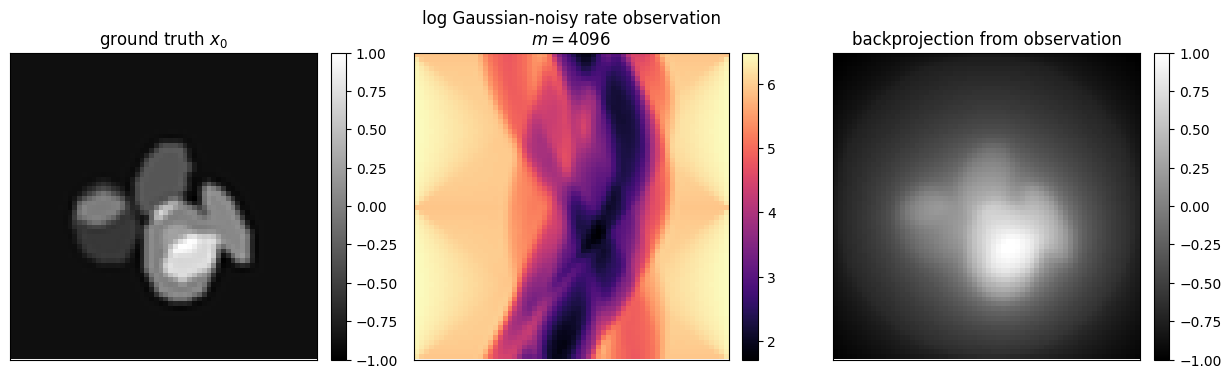

In [6]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(12.5, 3.8),
)

image_0 = axes[0].imshow(
    x_true[0, 0].detach().cpu(),
    cmap="gray",
    vmin=-1,
    vmax=1,
)
axes[0].set_title("ground truth $x_0$")
figure.colorbar(image_0, ax=axes[0], fraction=0.046, pad=0.04)

image_1 = axes[1].imshow(
    ct.display_observation_sinogram(y_obs).detach().cpu(),
    cmap="magma",
    aspect="auto",
)
observation_title = (
    "log Gaussian-noisy rate observation"
    if ct.observation_mode == "gaussian_rate"
    else "log observed Poisson counts"
)
axes[1].set_title(
    observation_title + f"\n$m={ct.obs_dim}$"
)
figure.colorbar(image_1, ax=axes[1], fraction=0.046, pad=0.04)

backprojection = ct.backproject_from_observation(y_obs)[0, 0]
image_2 = axes[2].imshow(
    backprojection.detach().cpu(),
    cmap="gray",
    vmin=-1,
    vmax=1,
)
axes[2].set_title("backprojection from observation")
figure.colorbar(image_2, ax=axes[2], fraction=0.046, pad=0.04)

for axis in axes:
    axis.set_xticks([])
    axis.set_yticks([])

figure.tight_layout()
if cfg.save_figures:
    figure.savefig(
        OUT / "observation.png",
        dpi=150,
        bbox_inches="tight",
    )
plt.show()

## 5. Methods

Every method uses the same active reward returned by `ct.reward(x, y_obs)`:

- Poisson log likelihood in `poisson_counts` mode;
- Gaussian squared-error likelihood on the nonlinear rate map $F(x)$ in
  `gaussian_rate` mode.

Thus the prior and samplers remain unchanged while only the observation model
is switched.

In [7]:
METHODS = {}

def register(name):
    def deco(fn):
        METHODS[name] = fn
        return fn
    return deco


def reward_and_grad(x, ct, y_obs):
    """(r, grad r) for a batch of particles. The oracle every method shares."""
    x = x.detach().requires_grad_(True)
    r = ct.reward(x, y_obs)
    g = torch.autograd.grad(r.sum(), x)[0]
    return r.detach(), g

### 5a. Classical reconstruction (deterministic reference)

FBP with a Hann-windowed ramp filter, plus plain backprojection for contrast.
Unobserved rays are interpolated rather than zero-filled -- a ramp filter reads
zeros as "no attenuation here" and streaks.

In [8]:
@register("FBP")
def method_fbp(model, ct, y_obs, cfg, seed):
    return ct.fbp_from_observation(
        y_obs,
        window="hann",
    )


@register("Backprojection")
def method_backprojection(model, ct, y_obs, cfg, seed):
    return ct.backproject_from_observation(y_obs)

### 5b. DPS (Diffusion Posterior Sampling)

Self-contained reverse-SDE sampler with a likelihood-gradient correction at each
step. Step size is normalised by $\|\nabla r\|$, which matters here because
$r$ is order $10^6$ at $m=18432$ and a raw step size would not transfer.

In [9]:
@register("DPS")
def method_dps(model, ct, y_obs, cfg, seed, step_scale=1.0, grad_clip=1.0):
    N, H = cfg.n_samples, cfg.img_size
    g = torch.Generator(device=DEVICE).manual_seed(seed)
    x = torch.randn(N, 1, H, H, device=DEVICE, generator=g)

    ts = torch.linspace(1.0, 1e-3, cfg.n_steps + 1, device=DEVICE)
    for i in range(cfg.n_steps):
        t, t_next = ts[i], ts[i + 1]
        dt = (t - t_next)
        tb = t.expand(N)

        with torch.no_grad():
            score = model(x, tb)

        # reverse diffusion step (VP-SDE: mean=(1-t), std=sqrt(t(2-t)))
        drift = -x / torch.clamp(1.0 - t, min=1e-3)
        noise = torch.randn(x.shape, device=DEVICE, generator=g)
        x = x + (drift - 2.0 * score) * (-dt) + torch.sqrt(2.0 * dt) * noise

        # likelihood correction, normalised by gradient magnitude
        _, gr = reward_and_grad(x, ct, y_obs)
        gn = gr.flatten(1).norm(dim=1).view(-1, 1, 1, 1).clamp(min=1e-12)
        x = (x + step_scale * float(dt) * (gr / gn) * math.sqrt(H * H)).detach()
        x = x.clamp(-3.0, 3.0)

    return x.clamp(-1.0, 1.0).detach()

### 5c. Multilevel SMC (the proposed method)

`ct_smc.py` uses the active `ct.reward` oracle. Therefore the same multilevel
prior hierarchy can target either the Poisson-count posterior or the new
Gaussian-rate posterior.

This notebook passes `likelihood_strength=1` and
`auto_calibrate_strength=False`, so it does not automatically weaken the
requested likelihood.

In [10]:
from ct_smc import run_multilevel_smc_scoreprior, SMCConfig


@register("SMC (ours)")
def method_smc(model, ct, y_obs, cfg, seed):
    smc_cfg = SMCConfig(
        img_size=cfg.img_size,
        num_smc_levels=cfg.smc_levels,
        num_ref_levels=cfg.smc_ref_levels,
        n_steps_ref_by_level=list(cfg.smc_steps),
        n_steps_smc_by_level=list(
            cfg.smc_steps[:cfg.smc_levels]
        ),
        n_ref_tail=cfg.smc_n_ref_tail,
        surrogate_mode=cfg.smc_surrogate,
        surrogate_chunk_size=cfg.reward_chunk,
        tail_stats_path=cfg.smc_tail_stats,

        # Use the requested full likelihood without ESS calibration.
        likelihood_strength=cfg.smc_likelihood_strength,
        auto_calibrate_strength=cfg.smc_auto_calibrate_strength,

        n_particles=cfg.n_samples,
        target_population=cfg.n_samples,
    )

    output = run_multilevel_smc_scoreprior(
        model,
        ct=ct,
        y_obs=y_obs,
        n_particles=cfg.n_samples,
        seed=seed,
        cfg=smc_cfg,
    )

    globals()["smc_out"] = output
    return output["samples"]

## 6. Run all methods

In [11]:
def psnr(a, b, data_range=2.0):
    mse = torch.mean((a - b) ** 2)
    return float(
        10.0
        * torch.log10(
            data_range ** 2
            / torch.clamp(mse, min=1e-12)
        )
    )


results = {}
for name, function in METHODS.items():
    start_time = time.time()
    samples = function(
        score_model,
        ct,
        y_obs,
        cfg,
        cfg.seed,
    )
    elapsed = time.time() - start_time

    mean = samples.mean(0, keepdim=True)

    with torch.no_grad():
        reward_values = ct.reward(samples, y_obs)

    residuals = ct.residual_summary(samples, y_obs)
    mean_residuals = ct.residual_summary(mean, y_obs)

    observation_rmse = residuals.get(
        "observation_rmse_mean",
        residuals["count_rmse_mean"],
    )

    results[name] = {
        "samples": samples,
        "mean": mean,
        "seconds": elapsed,
        "rmse": float(
            torch.sqrt(
                torch.mean((mean - x_true) ** 2)
            )
        ),
        "psnr": psnr(mean, x_true),
        "pearson_rms": residuals["pearson_rms_mean"],
        "pearson_rms_std": residuals.get(
            "pearson_rms_std",
            float("nan"),
        ),
        "deviance": residuals["deviance_per_ray_mean"],
        "count_rmse": residuals["count_rmse_mean"],
        "observation_rmse": observation_rmse,
        "pearson_rms_of_mean": mean_residuals[
            "pearson_rms_mean"
        ],
        "reward_mean": float(reward_values.mean()),
        "post_std": (
            float(samples.std(0).mean())
            if samples.shape[0] > 1
            else float("nan")
        ),
        "n": int(samples.shape[0]),
    }

    print(
        f"{name:18s} {elapsed:7.1f}s"
        f"   rmse={results[name]['rmse']:.4f}"
        f"   psnr={results[name]['psnr']:6.2f}"
        f"   standardized_residual="
        f"{results[name]['pearson_rms']:6.3f}"
        f"   r={results[name]['reward_mean']:.4e}"
    )

# Reference residual of the actual ground truth under the active noise model.
reference_residual = ct.residual_summary(x_true, y_obs)
expected_target = ct.residual_target

print()
print(
    f"{'ground truth':18s} {'(reference)':>26s}"
    f"   standardized_residual="
    f"{reference_residual['pearson_rms_mean']:6.3f}"
    f"   (target: ~{expected_target:.1f})"
)

_ref = reference_residual

FBP                    8.5s   rmse=0.0810   psnr= 27.85   standardized_residual=1764.601   r=-6.3771e+09
Backprojection         0.0s   rmse=0.3838   psnr= 14.34   standardized_residual=2450.198   r=-1.2295e+10
DPS                   11.1s   rmse=0.3732   psnr= 14.58   standardized_residual=2284.123   r=-1.0743e+10
loading tail stats: /usr/workspace/mlml/synthetic_64_256/mri_score_prior_dsm2000_outputs/score_prior_tail_behavior_stats.npz
MULTILEVEL SMC  levels: 5  steps: [100, 120, 140, 160, 180]
eta_by_level: ['0.8642', '0.7483', '0.6784', '0.6368', '0.5173']
likelihood_strength: 1.000e+00
surrogate: none  multiplier: 0.000e+00  m: 4096
level 1/5: N=512 ESS=1.0/512 unique=1
level 2/5: N=512 ESS=1.0/512 unique=1
level 3/5: N=512 ESS=1.0/512 unique=1
level 4/5: N=512 ESS=1.0/512 unique=1
level 5/5: N=512 ESS=1.0/512 unique=1
SMC (ours)            29.4s   rmse=0.2020   psnr= 19.91   standardized_residual=393.658   r=-3.1737e+08

ground truth                      (reference)   standardized_

### SMC level diagnostics

ESS per level is the health check. Sustained ESS well below the particle count,
or a unique-ancestor count in the single digits, means the level increments are
too coarse or the tempering is wrong -- not that the method failed.

 level      N       ESS   unique        eta
     1    512       1.0        1     0.8642
     2    512       1.0        1     0.7483
     3    512       1.0        1     0.6784
     4    512       1.0        1     0.6368
     5    512       1.0        1     0.5173


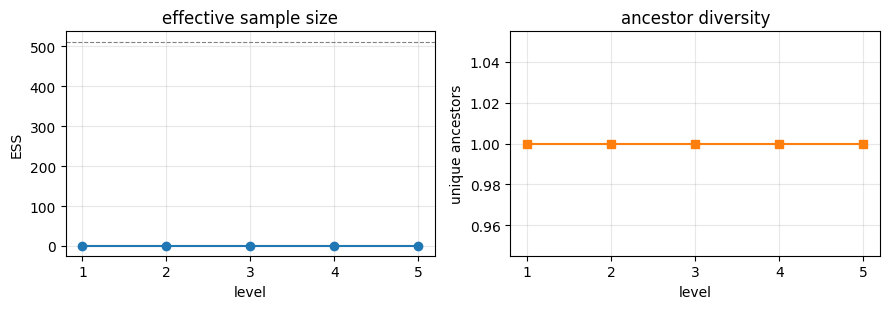

In [12]:
if "smc_out" in globals():
    o = smc_out
    print(f"{'level':>6} {'N':>6} {'ESS':>9} {'unique':>8} {'eta':>10}")
    for i, (n, e, u, et) in enumerate(zip(o["pop_by_level"], o["ess_by_level"],
                                          o["unique_ancestors"], o["eta_by_level"]), 1):
        print(f"{i:>6} {n:>6} {e:>9.1f} {u:>8} {et:>10.4f}")

    fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
    lv = range(1, len(o["ess_by_level"]) + 1)
    ax[0].plot(lv, o["ess_by_level"], "o-"); ax[0].set_xlabel("level"); ax[0].set_ylabel("ESS")
    ax[0].axhline(cfg.n_samples, ls="--", c="gray", lw=0.8); ax[0].set_title("effective sample size")
    ax[1].plot(lv, o["unique_ancestors"], "s-", c="C1")
    ax[1].set_xlabel("level"); ax[1].set_ylabel("unique ancestors"); ax[1].set_title("ancestor diversity")
    for a in ax: a.grid(alpha=0.3)
    fig.tight_layout()
    if cfg.save_figures: fig.savefig(OUT / "smc_levels.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Comparison

In [13]:
import pandas as pd

_columns = [
    "rmse",
    "psnr",
    "pearson_rms",
    "pearson_rms_std",
    "pearson_rms_of_mean",
    "deviance",
    "observation_rmse",
    "count_rmse",
    "reward_mean",
    "post_std",
    "n",
    "seconds",
]

comparison_df = pd.DataFrame(
    {
        method: {
            metric: values[metric]
            for metric in _columns
        }
        for method, values in results.items()
    }
).T

comparison_df.loc[
    "(ground truth)",
    "pearson_rms",
] = _ref["pearson_rms_mean"]
comparison_df.loc[
    "(ground truth)",
    "deviance",
] = _ref["deviance_per_ray_mean"]

comparison_df.index.name = "method"
comparison_df.to_csv(OUT / "comparison.csv")
comparison_df

# Backward-compatible variable used by the final JSON cell.
df = comparison_df
_cols = _columns

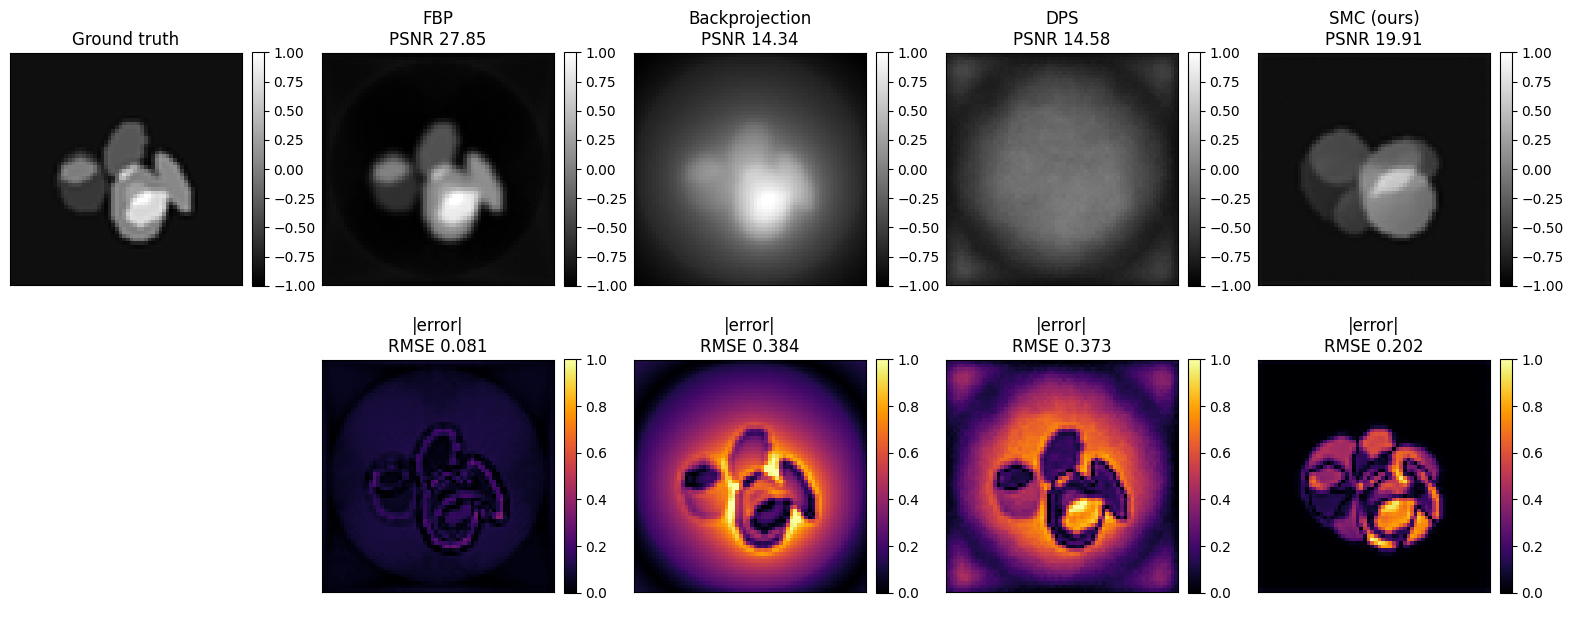

In [14]:
# ============================================================
# Comparison plot with colorbars
# ============================================================
# Top row: ground truth and posterior/sample means.
# Bottom row: absolute-error maps for each method.
# Colorbars show the numerical values for both reconstructions and errors.
# ============================================================

k = len(results)
fig, ax = plt.subplots(
    2,
    k + 1,
    figsize=(3.15 * (k + 1), 6.35),
    squeeze=False,
)

# -----------------------------
# Ground truth
# -----------------------------
im0 = ax[0, 0].imshow(
    x_true[0, 0].detach().cpu(),
    cmap="gray",
    vmin=-1,
    vmax=1,
)
ax[0, 0].set_title("Ground truth")
fig.colorbar(
    im0,
    ax=ax[0, 0],
    fraction=0.046,
    pad=0.04,
)

# There is no error map for the ground truth column.
ax[1, 0].axis("off")

# -----------------------------
# Method means and absolute errors
# -----------------------------
for j, (name, r) in enumerate(results.items(), start=1):
    mean_img = r["mean"][0, 0].detach().cpu()

    im_mean = ax[0, j].imshow(
        mean_img,
        cmap="gray",
        vmin=-1,
        vmax=1,
    )
    ax[0, j].set_title(f"{name}\nPSNR {r['psnr']:.2f}")
    fig.colorbar(
        im_mean,
        ax=ax[0, j],
        fraction=0.046,
        pad=0.04,
    )

    err = (r["mean"] - x_true)[0, 0].abs().detach().cpu()
    im_err = ax[1, j].imshow(
        err,
        cmap="inferno",
        vmin=0,
        vmax=1.0,
    )
    ax[1, j].set_title(f"|error|\nRMSE {r['rmse']:.3f}")
    fig.colorbar(
        im_err,
        ax=ax[1, j],
        fraction=0.046,
        pad=0.04,
    )

# Hide ticks but keep images and colorbars.
for axis in ax.ravel():
    axis.set_xticks([])
    axis.set_yticks([])

fig.tight_layout()

if cfg.save_figures:
    fig.savefig(
        OUT / "comparison.png",
        dpi=150,
        bbox_inches="tight",
    )

plt.show()


## 8. Flexible top-5 MAP particles by SMC level

For each SMC level, this displays exactly five MAP-like panels. The cell first
keeps reward-ranked particles that are visually distinct under a small RMSE
tolerance. If fewer than five distinct particles are available at a level, it
repeats the available MAP particles cyclically so every level has five panels.

This is a display/diagnostic cell only; it does not change the SMC algorithm or
resampling.


FLEXIBLE TOP-5 MAP PARTICLES FOR EACH SMC LEVEL
Particle source: smc_out['samples_by_level'] (post-resampling population)
Selection rule: show distinct particles when available; otherwise repeat MAPs
SMC level  1: 1 distinct particle(s) among 512 stored particles; showing 5 panels.
   All stored particles are identical (or numerically indistinguishable); MAP 1 is repeated.
   rank  1 | reward = -2.2337e+09 | root=300
   rank  2 | reward = -2.2337e+09 | root=300 | repeat of distinct #1
   rank  3 | reward = -2.2337e+09 | root=300 | repeat of distinct #1
   rank  4 | reward = -2.2337e+09 | root=300 | repeat of distinct #1
   rank  5 | reward = -2.2337e+09 | root=300 | repeat of distinct #1
SMC level  2: 1 distinct particle(s) among 512 stored particles; showing 5 panels.
   All stored particles are identical (or numerically indistinguishable); MAP 1 is repeated.
   rank  1 | reward = -5.9374e+08 | root=300
   rank  2 | reward = -5.9374e+08 | root=300 | repeat of distinct #1
   rank  3 | 

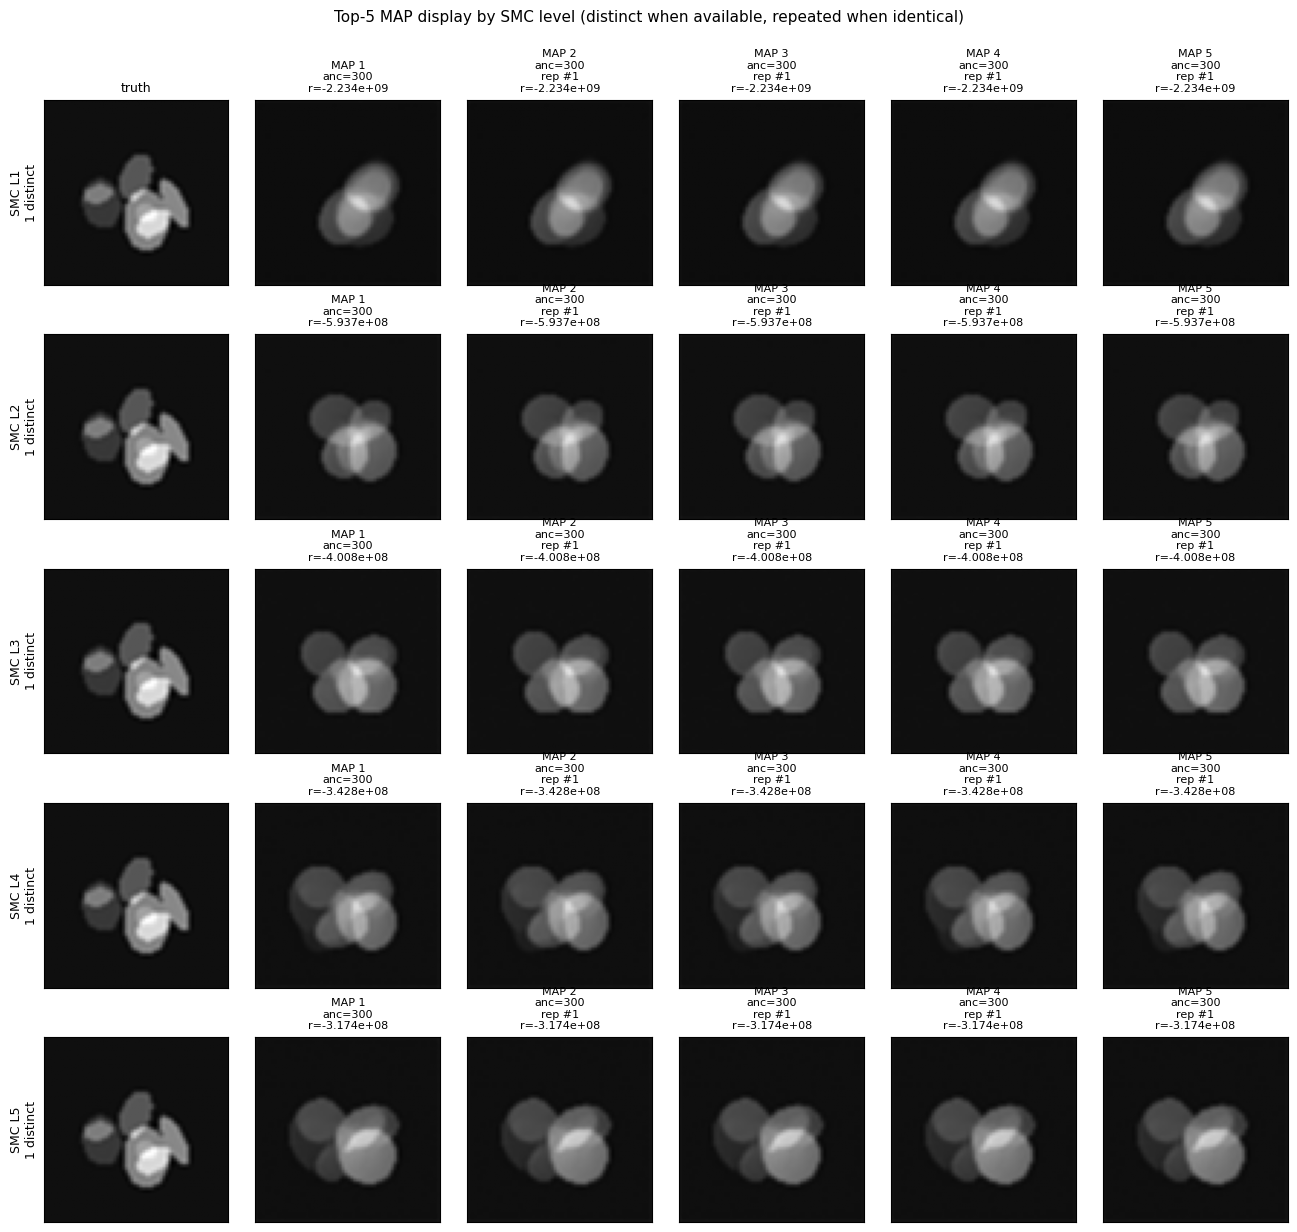

In [15]:
# ============================================================
# Flexible Top-5 MAP display for each SMC level (levels 1--5)
# - Prefer distinct particles when they exist.
# - If fewer than 5 distinct particles exist, repeat the best one(s)
#   so that each level always shows 5 MAP panels.
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

NUM_MAP_PARTICLES = int(globals().get("NUM_MAP_PARTICLES", 5))
MAP_REWARD_CHUNK_SIZE = int(globals().get("MAP_REWARD_CHUNK_SIZE", 16))
MAP_DISTINCT_RMSE_TOL = float(globals().get("MAP_DISTINCT_RMSE_TOL", 1e-7))

if "smc_out" not in globals():
    raise NameError("smc_out not found. Run the SMC method first.")

# Avoid `a or b` here: tensors/lists may not safely convert to bool.
samples_by_level = None
samples_key = None
for key in ("samples_by_level", "level_samples", "particles_by_level"):
    value = smc_out.get(key, None)
    if value is not None:
        samples_by_level = value
        samples_key = key
        break

if samples_by_level is None:
    raise KeyError(
        "Could not find per-level samples in smc_out. "
        "Expected one of: 'samples_by_level', 'level_samples', or "
        "'particles_by_level'."
    )

# Optional labels only for printing. They do NOT restrict selection.
root_ancestors_by_level = smc_out.get("ancestors_by_level", None)
local_branch_ids_by_level = smc_out.get("local_branch_ids_by_level", None)


def _as_image_batch(samples):
    if not torch.is_tensor(samples):
        samples = torch.as_tensor(samples)
    if samples.ndim == 3:
        samples = samples[:, None, :, :]
    if samples.ndim != 4:
        raise ValueError(
            "Expected level samples with shape (N,H,W) or (N,1,H,W); "
            f"received {tuple(samples.shape)}."
        )
    return samples


@torch.no_grad()
def _reward_in_chunks(samples, ct, y_obs, chunk_size=MAP_REWARD_CHUNK_SIZE):
    reward_parts = []
    reward_device = y_obs.device

    for sample_chunk in samples.split(max(1, int(chunk_size)), dim=0):
        reward_parts.append(
            ct.reward(sample_chunk.to(reward_device), y_obs)
            .detach()
            .to("cpu", dtype=torch.float64)
        )

    return torch.cat(reward_parts, dim=0)


@torch.no_grad()
def _pairwise_rmse(x, y):
    return torch.sqrt(torch.mean((x.float() - y.float()) ** 2))


@torch.no_grad()
def topk_map_flexible(
    samples,
    ct,
    y_obs,
    k=NUM_MAP_PARTICLES,
    distinct_tol=MAP_DISTINCT_RMSE_TOL,
):
    """Return exactly k display particles.

    First collect up to k reward-ranked, visually distinct particles.
    If fewer than k distinct particles exist, repeat the selected particles
    cyclically. When only one unique particle exists, MAP 1 is repeated.
    """
    samples = _as_image_batch(samples)
    n_candidates = int(samples.shape[0])

    if n_candidates == 0:
        raise ValueError("The level sample cloud is empty.")

    rewards = _reward_in_chunks(samples, ct, y_obs)
    order = torch.argsort(rewards, descending=True).tolist()

    distinct_indices = []

    for candidate_index in order:
        candidate = samples[candidate_index]
        is_duplicate = False

        for previous_index in distinct_indices:
            rmse = _pairwise_rmse(candidate, samples[previous_index])
            if float(rmse.detach().cpu()) <= float(distinct_tol):
                is_duplicate = True
                break

        if is_duplicate:
            continue

        distinct_indices.append(candidate_index)

        if len(distinct_indices) >= int(k):
            break

    if not distinct_indices:
        distinct_indices = [int(order[0])]

    # Always output exactly k display slots.
    display_indices = []
    repeat_of = []

    for j in range(int(k)):
        distinct_position = j % len(distinct_indices)
        display_indices.append(distinct_indices[distinct_position])
        repeat_of.append(distinct_position + 1)

    reward_index = torch.as_tensor(display_indices, dtype=torch.long)
    sample_index = torch.as_tensor(
        display_indices,
        dtype=torch.long,
        device=samples.device,
    )

    meta = {
        "n_candidates": n_candidates,
        "n_distinct": len(distinct_indices),
        "n_display": int(k),
        "distinct_indices": distinct_indices,
        "display_indices": display_indices,
        "repeat_of": repeat_of,
        "all_identical": len(distinct_indices) == 1,
    }

    return rewards[reward_index], samples[sample_index], meta


def _safe_label_array(label_list, level_idx, n_expected):
    if label_list is None or len(label_list) < level_idx:
        return None

    arr_obj = label_list[level_idx - 1]
    if torch.is_tensor(arr_obj):
        arr = arr_obj.detach().cpu().numpy().reshape(-1)
    else:
        arr = np.asarray(arr_obj).reshape(-1)

    if len(arr) != n_expected:
        return None

    return arr


level_map_results = {}

print("=" * 100)
print("FLEXIBLE TOP-5 MAP PARTICLES FOR EACH SMC LEVEL")
print(f"Particle source: smc_out[{samples_key!r}] (post-resampling population)")
print("Selection rule: show distinct particles when available; otherwise repeat MAPs")
print("=" * 100)

for ell, level_samples in enumerate(samples_by_level, start=1):
    if level_samples is None:
        continue

    level_samples = _as_image_batch(level_samples)

    if int(level_samples.shape[0]) < 1:
        continue

    rw, mp, meta = topk_map_flexible(
        level_samples,
        ct,
        y_obs,
        k=NUM_MAP_PARTICLES,
        distinct_tol=MAP_DISTINCT_RMSE_TOL,
    )

    root_labels = _safe_label_array(
        root_ancestors_by_level,
        ell,
        meta["n_candidates"],
    )
    branch_labels = _safe_label_array(
        local_branch_ids_by_level,
        ell,
        meta["n_candidates"],
    )

    display_root_labels = []
    display_branch_labels = []

    for particle_index in meta["display_indices"]:
        display_root_labels.append(
            int(root_labels[particle_index]) if root_labels is not None else None
        )
        display_branch_labels.append(
            int(branch_labels[particle_index]) if branch_labels is not None else None
        )

    meta["display_root_labels"] = display_root_labels
    meta["display_branch_labels"] = display_branch_labels

    level_map_results[ell] = (rw, mp, meta)

    print(
        f"SMC level {ell:>2d}: {meta['n_distinct']} distinct particle(s) among "
        f"{meta['n_candidates']} stored particles; showing "
        f"{NUM_MAP_PARTICLES} panels."
    )

    if meta["all_identical"]:
        print(
            "   All stored particles are identical (or numerically "
            "indistinguishable); MAP 1 is repeated."
        )
    elif meta["n_distinct"] < NUM_MAP_PARTICLES:
        print(
            f"   Only {meta['n_distinct']} distinct particles were found; "
            "remaining panels are repeated cyclically."
        )
    else:
        print("   At least five distinct particles were found; all panels are distinct.")

    for j in range(NUM_MAP_PARTICLES):
        repeat_note = ""
        if meta["repeat_of"][j] != j + 1:
            repeat_note = f" | repeat of distinct #{meta['repeat_of'][j]}"

        root_note = ""
        branch_note = ""

        if meta["display_root_labels"][j] is not None:
            root_note = f" | root={meta['display_root_labels'][j]}"

        if meta["display_branch_labels"][j] is not None:
            branch_note = f" | branch={meta['display_branch_labels'][j]}"

        print(
            f"   rank {j + 1:>2d} | reward = {float(rw[j]):.6g}"
            f"{root_note}{branch_note}{repeat_note}"
        )

# ------------------------------------------------------------
# Plot truth + exactly five MAP panels for each level
# ------------------------------------------------------------
if level_map_results:
    nrow = len(level_map_results)

    fig, ax = plt.subplots(
        nrow,
        NUM_MAP_PARTICLES + 1,
        figsize=(2.2 * (NUM_MAP_PARTICLES + 1), 2.45 * nrow),
        squeeze=False,
    )

    level_items = sorted(level_map_results.items(), key=lambda item: item[0])

    for row, (ell, (rw, mp, meta)) in enumerate(level_items):
        ax[row, 0].imshow(
            x_true[0, 0].detach().cpu(),
            cmap="gray",
            vmin=-1,
            vmax=1,
        )
        ax[row, 0].set_ylabel(
            f"SMC L{ell}\n{meta['n_distinct']} distinct",
            fontsize=9,
        )
        ax[row, 0].set_title("truth" if row == 0 else "", fontsize=9)

        for rank in range(NUM_MAP_PARTICLES):
            axis = ax[row, rank + 1]
            axis.imshow(
                mp[rank, 0].detach().cpu(),
                cmap="gray",
                vmin=-1,
                vmax=1,
            )

            repeat_note = ""
            if meta["repeat_of"][rank] != rank + 1:
                repeat_note = f"\nrep #{meta['repeat_of'][rank]}"

            aux_note = ""
            if meta["display_branch_labels"][rank] is not None:
                aux_note = f"\nbr={meta['display_branch_labels'][rank]}"
            elif meta["display_root_labels"][rank] is not None:
                aux_note = f"\nanc={meta['display_root_labels'][rank]}"

            axis.set_title(
                f"MAP {rank + 1}{aux_note}{repeat_note}"
                f"\nr={float(rw[rank]):.4g}",
                fontsize=8,
            )

        for axis in ax[row]:
            axis.set_xticks([])
            axis.set_yticks([])

    fig.suptitle(
        "Top-5 MAP display by SMC level "
        "(distinct when available, repeated when identical)",
        fontsize=11,
        y=1.002,
    )
    fig.tight_layout()

    if getattr(cfg, "save_figures", False):
        figure_path = OUT / "smc_levels_top5_flexible_map_particles.png"
        fig.savefig(figure_path, dpi=150, bbox_inches="tight")
        print("saved", figure_path)

    plt.show()

else:
    print("No per-level MAP results were produced.")


### Measurement-space residuals

The plotted standardized residual is defined so that the ground-truth value is
approximately one under either sampled noise model:

- Poisson mode:
  $\sqrt{m^{-1}\sum_i(y_i-\lambda_i)^2/\lambda_i}$;
- Gaussian-rate mode:
  $\sqrt{m^{-1}\sum_i(y_i-F_i(x))^2/\sigma_F^2}$.

When the Gaussian-rate observation is exact (`sample_observation_noise=False`),
the ground-truth target is zero instead.

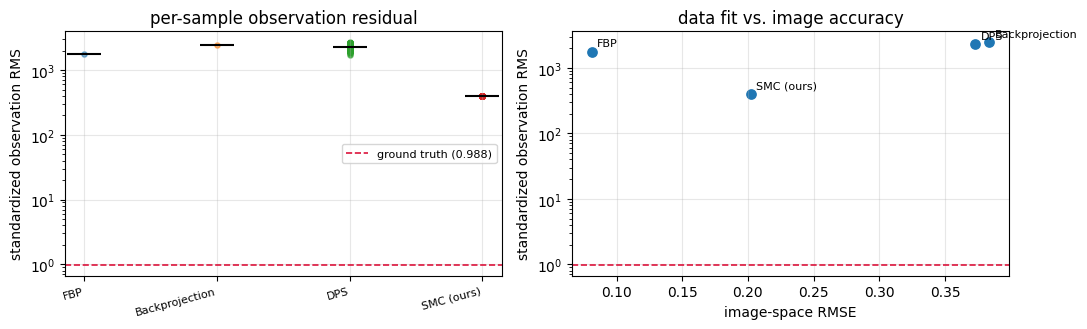

In [16]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(11, 3.4),
)
method_names = list(results.keys())

for index, name in enumerate(method_names):
    standardized_rms = ct.measurement_residuals(
        results[name]["samples"],
        y_obs,
    )["pearson_rms"]

    axes[0].scatter(
        [index] * len(standardized_rms),
        standardized_rms.cpu(),
        s=14,
        alpha=0.55,
    )
    axes[0].scatter(
        [index],
        [float(standardized_rms.mean())],
        marker="_",
        s=600,
        c="k",
        zorder=3,
    )

axes[0].axhline(
    _ref["pearson_rms_mean"],
    ls="--",
    c="crimson",
    lw=1.2,
    label=(
        "ground truth "
        f"({_ref['pearson_rms_mean']:.3f})"
    ),
)
axes[0].set_xticks(range(len(method_names)))
axes[0].set_xticklabels(
    method_names,
    rotation=15,
    ha="right",
    fontsize=8,
)
axes[0].set_ylabel("standardized observation RMS")
axes[0].set_yscale("log")
axes[0].set_title("per-sample observation residual")
axes[0].legend(fontsize=8)

axes[1].scatter(
    [results[name]["rmse"] for name in method_names],
    [results[name]["pearson_rms"] for name in method_names],
    s=45,
)

for name in method_names:
    axes[1].annotate(
        name,
        (
            results[name]["rmse"],
            results[name]["pearson_rms"],
        ),
        fontsize=8,
        xytext=(4, 4),
        textcoords="offset points",
    )

axes[1].axhline(
    _ref["pearson_rms_mean"],
    ls="--",
    c="crimson",
    lw=1.2,
)
axes[1].set_xlabel("image-space RMSE")
axes[1].set_ylabel("standardized observation RMS")
axes[1].set_yscale("log")
axes[1].set_title("data fit vs. image accuracy")

for axis in axes:
    axis.grid(alpha=0.3)

figure.tight_layout()
if cfg.save_figures:
    figure.savefig(
        OUT / "residuals.png",
        dpi=150,
        bbox_inches="tight",
    )
plt.show()

## 9. Posterior sampling quality

The same four-axis report is retained. In Gaussian-rate mode,
`chi2_per_ray` is the mean squared rate residual divided by
$\sigma_F^2$, so its target remains one when observation noise is sampled.

For the exact-observation diagnostic (`sample_observation_noise=False`), use
image-space contraction and observation RMSE directly; a chi-square target of
one no longer applies because the realized observation noise is zero.

In [17]:
import ct_metrics as metrics
importlib.reload(metrics)

# Genuine prior draws, as the reference distribution for typicality.
prior_ref = torch.cat([common.sample_cylinder_image(i, cfg.img_size, seed=999, device=DEVICE)
                       for i in range(16)])

reports = {}
for name, r in results.items():
    if r["samples"].shape[0] < 2:
        continue
    reports[name] = metrics.posterior_report(
        ct, score_model, r["samples"], y_obs, x_true, prior_ref, seed=cfg.seed)

print(metrics.format_report(reports))

metric                         DPS  SMC (ours)   target
----------------------------------------------------------
chi2_per_ray             5.246e+06    1.55e+05   = 1  (< 1 means the noise was fitted)
chi2_z                   2.374e+08   7.013e+06   |z| < ~3
dsm_z                        58.17      -1.473   ~0  (large = off the prior manifold)
participation_ratio          145.2           0   large  (1.0 = collapsed)
distinct_fraction                1    0.001953   -> 1
contraction_ratio            1.404           0   = 1  (< 1 = overconfident)
coverage_90                      1           0   -> 0.90


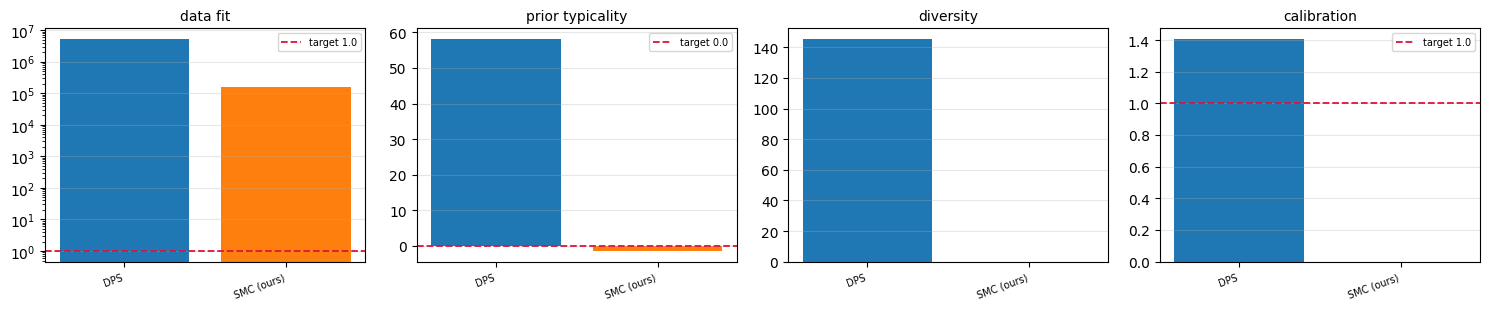

In [18]:
fig, ax = plt.subplots(1, 4, figsize=(15, 3.2))
names = list(reports)
panels = [("chi2_per_ray", 1.0, "data fit", True),
          ("dsm_z", 0.0, "prior typicality", False),
          ("participation_ratio", None, "diversity", False),
          ("contraction_ratio", 1.0, "calibration", False)]
for a, (key, target, title, logy) in zip(ax, panels):
    vals = [reports[n][key] for n in names]
    a.bar(range(len(names)), vals, color=[f"C{i}" for i in range(len(names))])
    if target is not None:
        a.axhline(target, ls="--", c="crimson", lw=1.3, label=f"target {target}")
        a.legend(fontsize=7)
    if logy and min(vals) > 0:
        a.set_yscale("log")
    a.set_xticks(range(len(names)))
    a.set_xticklabels(names, rotation=20, ha="right", fontsize=7)
    a.set_title(title, fontsize=10); a.grid(alpha=0.3, axis="y")
fig.tight_layout()
if cfg.save_figures: fig.savefig(OUT / "posterior_quality.png", dpi=150, bbox_inches="tight")
plt.show()

### Simulation-based calibration (optional, expensive)

The four axes above can fail to reject a bad sampler. SBC can actually certify
one: draw $x^\star$ from the prior, simulate $y$, sample, and record the rank of
$x^\star$ among the samples. Under exact posterior sampling that rank is
**uniform**. A U-shaped histogram means the posterior is too narrow, a peaked
one too wide, a skewed one biased.

Costs `n_trials` full sampler runs, so use reduced settings. Set `RUN_SBC=True`.

In [19]:
RUN_SBC = False        # set True to run; costs n_trials full sampler runs

if RUN_SBC:
    def _prior_draw(s):
        return common.sample_cylinder_image(0, cfg.img_size, seed=s, device=DEVICE)

    def _sampler(y_k, n, s):
        return METHODS["SMC (ours)"](score_model, ct, y_k,
                                     Cfg(**{**cfg.__dict__, "n_samples": n}), s)

    sbc = metrics.simulation_based_calibration(
        ct, _sampler, _prior_draw, n_trials=20, n_samples=16, seed=cfg.seed)
    print(f"SBC: {sbc['n_trials']} trials, chi2={sbc['chi2']:.2f}, p={sbc['p_value']:.3f}")
    print("  p > 0.05 is consistent with correct sampling (not proof of it)")

    fig, a = plt.subplots(figsize=(4.6, 3.0))
    a.bar(range(len(sbc["histogram"])), sbc["histogram"])
    a.axhline(len(sbc["ranks"]) / len(sbc["histogram"]), ls="--", c="crimson",
              label="uniform")
    a.set_xlabel("rank bin"); a.set_ylabel("count"); a.legend(fontsize=8)
    a.set_title("SBC rank histogram")
    fig.tight_layout()
    if cfg.save_figures: fig.savefig(OUT / "sbc_ranks.png", dpi=150, bbox_inches="tight")
    plt.show()

In [20]:
import json

json.dump(
    {
        "fingerprint": ct.fingerprint(
            y_obs=y_obs,
            x_true=x_true,
        ),
        "observation_model": ct.observation_mode,
        "gaussian_rate_noise_std": (
            ct.gaussian_rate_noise_std
            if ct.observation_mode == "gaussian_rate"
            else None
        ),
        "sample_observation_noise": cfg.sample_observation_noise,
        "config": {
            key: (
                str(value)
                if isinstance(value, pathlib.Path)
                else value
            )
            for key, value in cfg.__dict__.items()
        },
        "regime": report,
        "ground_truth_residuals": _ref,
        "posterior_quality": {
            method: {
                metric: value
                for metric, value in method_report.items()
            }
            for method, method_report in reports.items()
        },
        "results": {
            method: {
                metric: values[metric]
                for metric in _cols
            }
            for method, values in results.items()
        },
    },
    open(OUT / "run.json", "w"),
    indent=2,
)

print("wrote", OUT / "run.json")

wrote ct_transmission_outputs/run.json
